# 🦜 LangChain and LangGraph — Composable LLM Apps and Stateful Agent Graphs

> **What you'll learn:** when a framework actually helps (and when plain SDK code is better); LangChain's building blocks — chat models, messages, prompt templates, LCEL runnables, structured output, tools, the `create_agent` API, loaders, splitters, vector stores, and retrievers; then **LangGraph** for real applications — state graphs, conditional routing, reducers, checkpointers and resuming, human-in-the-loop interrupts, streaming, subgraphs, retries, and a corrective RAG graph. You finish by building and *measuring* an assistant over real documents with tools, retrieval, a human approval step, and checkpoint resume.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [RAG From Scratch](02_RAG_From_Scratch.ipynb) (chunking, embeddings, retrieval metrics, citations) · [Python Internals and Concurrency](../00_Foundations/05_Python_Internals_and_Concurrency.ipynb) (async basics) |
| **Tested with** | Python 3.12 · langchain 1.4 · langchain-core 1.6 · langchain-openai 1.6 · langgraph 1.2 · langgraph-checkpoint-sqlite 3.1 · sentence-transformers 6.0 · a local **gpt-oss-20b** served by llama.cpp |
| **Interview relevance** | ⭐⭐⭐ Very high — "framework or raw SDK?", "what is LCEL?", "how does tool calling work?", "design an agent with human approval", "how do checkpointers let you resume?", "what is corrective RAG?", "how do you trace and evaluate an agent?" |

## 🤔 What Is LangChain (and LangGraph)?

**LangChain** is a Python library of *standard parts* for LLM applications: one interface for many chat models, prompt templates, parsers, tools, document loaders, text splitters, vector stores, and retrievers. Every part is a **Runnable** — an object with the same methods (`invoke`, `batch`, `stream`, `ainvoke`) — so parts snap together with the `|` operator.

**LangGraph** (from the same team) is a library for **stateful workflows**: you draw your app as a graph of steps (nodes) connected by arrows (edges), with a shared *state* flowing through it. It adds the things real agents need: loops, branches, saving progress after every step (**checkpoints**), pausing for a human (**interrupts**), and streaming.

**Analogy — LEGO and a flowchart with a save button.**

- LangChain parts are **LEGO bricks**: every brick has the same studs (the Runnable interface), so a prompt brick clicks onto a model brick, which clicks onto a parser brick.
- LangGraph is a **flowchart on a whiteboard** where each box is a step, diamonds are decisions, and — unlike a whiteboard — the flowchart *remembers where it stopped*, can *wait for a manager's signature*, and can *resume tomorrow*.

```
 LangChain (a pipe of bricks)            LangGraph (a graph with state + checkpoints)

 prompt ─► chat model ─► parser          START ─► retrieve ─► grade ─┬─(relevant)──► generate ─► END
                                                        ▲            └─(not relevant)─► rewrite ─┐
                                                        └────────────────────────────────────────┘
                                                   💾 state saved after every step · ⏸ interrupt() pauses for a human
```

Since version 1.0 the two fit together: LangChain's high-level agent (`create_agent`) is itself **built on LangGraph**.

## 🎯 Why It Matters

- **It is the most common LLM application stack in job descriptions.** "LangChain / LangGraph / LlamaIndex" appears in a large share of AI-engineer postings, and many production agents (support bots, research assistants, coding agents) run on LangGraph.
- **The hard parts of agents are not the prompts.** They are state, retries, pausing for approval, resuming after a crash, streaming progress to a UI, and tracing what happened. LangGraph exists for exactly these.
- **Frameworks can also hurt.** Extra layers hide the actual HTTP request, add dependency churn (old LangChain code from 2023 no longer imports), and make debugging harder. Knowing *when not to use* a framework is a senior-level signal.
- **In interviews** expect: *"What is LCEL / a Runnable?"*, *"How does tool calling work under the hood?"*, *"Chain vs agent vs graph?"*, *"How would you add human approval before an agent sends an email?"*, *"How do you resume a failed multi-step run?"*, *"Explain corrective RAG"*, *"How do you evaluate an agent?"*, and *"Would you use a framework at all?"* This notebook answers each with running code and measurements.

## ✅ By the End You Can

- [ ] Decide between raw SDK code, LangChain, and LangGraph for a use case — and defend it with measured overhead
- [ ] Compose prompts, models, parsers, and plain functions into LCEL chains, and run them with `batch`, `stream`, and `async`
- [ ] Get validated structured output, define tools, and build a tool-calling agent with `create_agent`
- [ ] Build retrieval pipelines (loader → splitter → embeddings → vector store → retriever) and a RAG chain with checked citations
- [ ] Build LangGraph graphs with conditional routing, reducers, checkpointers, interrupts, streaming, subgraphs, and retries
- [ ] Implement a mini runnable pipe and a tiny state-graph executor from scratch and prove they match the libraries

## 📋 Table of Contents

1. [When a Framework Helps vs Hurts](#1.-When-a-Framework-Helps-vs-Hurts-🟢)
2. [Chat Models, Messages, and Prompt Templates](#2.-Chat-Models,-Messages,-and-Prompt-Templates-🟢)
3. [LCEL Runnables: Pipe, Parallel, Passthrough](#3.-LCEL-Runnables:-Pipe,-Parallel,-Passthrough-🟡)
4. [Batch, Stream, and Async](#4.-Batch,-Stream,-and-Async-🟡)
5. [Structured Output](#5.-Structured-Output-🟡)
6. [Tools and Tool Calling](#6.-Tools-and-Tool-Calling-🟡)
7. [Agents With create_agent](#7.-Agents-With-create_agent-🟡)
8. [Retrieval: Loaders, Splitters, Vector Stores, Retrievers](#8.-Retrieval:-Loaders,-Splitters,-Vector-Stores,-Retrievers-🟢)
9. [A RAG Chain With Citations](#9.-A-RAG-Chain-With-Citations-🟡)
10. [LangGraph: State, Nodes, Edges, and Routing](#10.-LangGraph:-State,-Nodes,-Edges,-and-Routing-🟢)
11. [State Reducers](#11.-State-Reducers-🟡)
12. [Checkpointers, Threads, and Resuming](#12.-Checkpointers,-Threads,-and-Resuming-🟡)
13. [Human-in-the-Loop Interrupts](#13.-Human-in-the-Loop-Interrupts-🟡)
14. [Streaming Steps, Tokens, and Custom Events](#14.-Streaming-Steps,-Tokens,-and-Custom-Events-🟡)
15. [Subgraphs, Retries, and Error Handling](#15.-Subgraphs,-Retries,-and-Error-Handling-🔴)
16. [A Corrective RAG Graph](#16.-A-Corrective-RAG-Graph-🔴)
17. [Tracing and Observability](#17.-Tracing-and-Observability-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-PEP-Assistant-With-Tools,-RAG,-Approval,-and-Resume) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cells below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**Which packages?** LangChain 1.x is split into small packages: `langchain-core` (the Runnable interface, messages, prompts, tools), `langchain` (agents and middleware), one package per provider (`langchain-openai` here), `langchain-text-splitters`, `langchain-huggingface` (local embeddings), and `langgraph` (+ `langgraph-checkpoint-sqlite` for a file-based checkpointer). We deliberately do **not** use `langchain-community`: its maintainers are sunsetting it (importing it prints a deprecation warning — see Pitfall 1).

**Downloads (first run only):** ten Python Enhancement Proposals (PEPs) from the official `python/peps` GitHub repository (~450 KB, public domain, cached in `_outputs/`), and the embedding model `sentence-transformers/all-MiniLM-L6-v2` (~90 MB).

**The LLM.** Every LLM call goes to an **OpenAI-compatible server**, configured by three environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | where the server listens |
| `LLM_MODEL` | `gpt-oss-20b` | model id the server exposes |
| `LLM_API_KEY` | `local` | local servers ignore it; hosted providers need a real key |

To start a free local server on a Mac: `brew install llama.cpp`, then `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (or `-m /path/to/gpt-oss-20b-MXFP4.gguf`). The **same code works** with Ollama (`LLM_BASE_URL=http://localhost:11434/v1`), LM Studio (`http://localhost:1234/v1`), or OpenAI (`https://api.openai.com/v1` with your key and a model such as `gpt-4.1-mini`) — only the variables change.

**About gpt-oss.** It is a *reasoning* model: before answering it writes hidden reasoning, and those tokens count toward `max_tokens`. We therefore give generations a generous budget (1024) and ask the server for **low reasoning effort** through llama.cpp's chat-template option (`extra_body={"chat_template_kwargs": {"reasoning_effort": "low"}}`), which the Setup cell measures. Outputs are non-deterministic, so the notebook never asserts on exact generated text — it checks structure or computes metrics, and conclusions say "on this run".

**Keep it small.** The local server has only a few parallel slots and an 8K-token context per slot, so LLM loops here are tens of calls, at most two run at once, and prompts stay a few thousand tokens.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "langchain>=1.0" "langchain-core>=1.0" "langchain-openai>=1.0" "langchain-huggingface>=1.0" "langchain-text-splitters>=1.0" "langgraph>=1.0" "langgraph-checkpoint-sqlite>=3.0" "sentence-transformers>=5" "openai>=1.0" pandas matplotlib

import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")      # avoids a fork warning from the Rust tokenizers
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")    # keep download bars out of saved outputs

import asyncio
import importlib.metadata as md
import json
import operator
import re
import sqlite3
import sys
import time
import urllib.request
import warnings
from operator import itemgetter
from pathlib import Path
from typing import Annotated, Literal, TypedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub.utils import logging as hf_logging
from openai import OpenAI
from pydantic import BaseModel, Field
from transformers.utils import logging as transformers_logging

hf_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()                   # hide the "Loading weights" bar

print(f"Python {sys.version.split()[0]} | " + " | ".join(
    f"{p} {md.version(p)}" for p in ["langchain", "langchain-core", "langchain-openai", "langgraph",
                                     "langgraph-checkpoint-sqlite", "sentence-transformers"]))

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_colwidth", 80)
OUTPUT_DIR = Path("_outputs") / "langchain_langgraph"         # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, float):
        ok = isinstance(got, (int, float)) and abs(got - expected) < 1e-6
    else:
        ok = got == expected
    assert ok, f"❌ {name}: got {got!r} — not quite. {hint}"
    print(f"✅ {name}: correct!")


def normalize_text(text):
    """Lower-case and collapse whitespace; gpt-oss often writes narrow no-break spaces (U+202F), e.g. 'PEP\u202f8'."""
    return " ".join(text.replace("\u202f", " ").replace("\u00a0", " ").split()).lower()

Python 3.12.11 | langchain 1.4.0 | langchain-core 1.6.3 | langchain-openai 1.6.2 | langgraph 1.2.11 | langgraph-checkpoint-sqlite 3.1.1 | sentence-transformers 6.0.1


Now connect to the LLM server. If it is not running, the cell stops with instructions instead of pretending.

In [2]:
from langchain_openai import ChatOpenAI

LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")
client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY, timeout=180, max_retries=2)

try:
    served = [m.id for m in client.models.list().data]
    print(f"✅ LLM server at {LLM_BASE_URL} — models: {served}")
except Exception as exc:
    raise RuntimeError(
        f"This notebook needs an OpenAI-compatible LLM server at {LLM_BASE_URL} ({type(exc).__name__}).\n"
        "Start one locally:  brew install llama.cpp  &&  llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja\n"
        "…or point LLM_BASE_URL / LLM_MODEL / LLM_API_KEY at Ollama, LM Studio, or a hosted provider."
    ) from exc

LOW_REASONING = {"chat_template_kwargs": {"reasoning_effort": "low"}}   # llama.cpp option for gpt-oss


def make_llm(**overrides):
    """One place to configure the chat model: the local server, generous token budget, low reasoning effort."""
    params = dict(base_url=LLM_BASE_URL, model=LLM_MODEL, api_key=LLM_API_KEY, temperature=0,
                  max_tokens=1024, timeout=180, max_retries=2, extra_body=LOW_REASONING)
    params.update(overrides)
    return ChatOpenAI(**params)


llm = make_llm()
MAX_CONCURRENCY = 2      # the shared local server has few slots; stay polite

✅ LLM server at http://127.0.0.1:8080/v1 — models: ['gpt-oss-20b']


## 1. When a Framework Helps vs Hurts 🟢

A **framework** is someone else's structure for your code. It pays off when it removes work you would otherwise repeat — and costs you when it hides what is happening.

| A framework **helps** when… | A framework **hurts** when… |
|---|---|
| you swap between model providers or run many models | you make one or two simple calls to one provider |
| you need standard parts: splitters, vector stores, retrievers, tool schemas | you need exact control of the HTTP request (new provider features land in the raw SDK first) |
| you need **state, retries, checkpoints, human approval, streaming** for multi-step agents (LangGraph) | the team cannot debug the extra layers, or the dependency churn is a risk |
| you want tracing/evaluation integrations for free | latency budgets are microseconds (rare for LLM apps — we measure below) |

**The one rule to remember:** *start with the simplest code that works; adopt a framework for a concrete feature you need (graphs with persistence, tool schemas, integrations), not for "chains".*

First, our **real documents**: ten Python Enhancement Proposals (PEPs) — the design documents that introduced f-strings, the walrus operator, pattern matching, type hints, and the optional GIL. We use them throughout the notebook.

In [3]:
PEP_NUMBERS = [8, 20, 257, 484, 492, 498, 572, 634, 695, 703]
PEP_DIR = OUTPUT_DIR / "peps"
PEP_DIR.mkdir(exist_ok=True)
for number in PEP_NUMBERS:
    path = PEP_DIR / f"pep-{number:04d}.rst"
    if not path.exists():                                   # download once, then reuse the cached copy
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/python/peps/main/peps/pep-{number:04d}.rst", path)

pep_text = {int(p.stem.split("-")[1]): p.read_text(encoding="utf-8") for p in sorted(PEP_DIR.glob("pep-*.rst"))}


def parse_header(text):
    """PEP files start with 'Key: value' lines (values may continue on indented lines)."""
    fields, key = {}, None
    for line in text.split("\n\n", 1)[0].splitlines():
        match = re.match(r"^([A-Za-z-]+):\s*(.*)$", line)
        if match:
            key = match.group(1)
            fields[key] = match.group(2).strip()
        elif key and line.startswith(" "):
            fields[key] += " " + line.strip()
    return fields


def rst_section(text, heading):
    """Body of a top-level reStructuredText section such as 'Abstract' (empty string if absent)."""
    match = re.search(rf"^{re.escape(heading)}\n=+\n(.*?)(?=^[^\n]+\n=+\n|\Z)", text, re.M | re.S)
    return match.group(1).strip() if match else ""


def pep_intro(number, max_chars=1500):
    """The Abstract of a PEP, or its Introduction when there is no Abstract (PEP 8 has none)."""
    text = pep_text[number]
    return (rst_section(text, "Abstract") or rst_section(text, "Introduction"))[:max_chars]


pep_headers = {n: parse_header(t) for n, t in pep_text.items()}
corpus_table = pd.DataFrame([{"pep": n, "title": h["Title"], "status": h["Status"], "python": h.get("Python-Version", "—"),
                              "size_kb": round(len(pep_text[n].encode()) / 1024, 1)} for n, h in pep_headers.items()])
print(f"{len(pep_text)} PEPs, {corpus_table.size_kb.sum():.0f} KB total")
corpus_table

10 PEPs, 430 KB total


,pep,title,status,python,size_kb
0,8,Style Guide for Python Code,Active,—,49.6
1,20,The Zen of Python,Active,—,1.6
2,257,Docstring Conventions,Active,—,10.3
3,484,Type Hints,Final,3.5,86.5
4,492,Coroutines with async and await syntax,Final,3.5,48.0
5,498,Literal String Interpolation,Final,3.6,24.5
6,572,Assignment Expressions,Final,3.8,45.9
7,634,Structural Pattern Matching: Specification,Final,3.10,22.6
8,695,Type Parameter Syntax,Final,3.12,56.2
9,703,Making the Global Interpreter Lock Optional in CPython,Final,3.13,84.3


Now the **same task two ways** — summarize the abstract of PEP 572 in one sentence — with the raw OpenAI SDK and with LangChain.

In [4]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableParallel, RunnablePassthrough

SYSTEM = "You summarize Python Enhancement Proposals for busy engineers in one plain sentence."
abstract_572 = rst_section(pep_text[572], "Abstract")


# --- raw SDK: explicit and dependency-light -------------------------------------------------
def summarize_raw(text):
    response = client.chat.completions.create(
        model=LLM_MODEL, temperature=0, max_tokens=1024, extra_body=LOW_REASONING,
        messages=[{"role": "system", "content": SYSTEM}, {"role": "user", "content": text}],
    )
    return response.choices[0].message.content.strip()


# --- LangChain: prompt | model | parser — each part swappable --------------------------------
summarize_chain = ChatPromptTemplate.from_messages([("system", SYSTEM), ("human", "{text}")]) | llm | StrOutputParser()

start = time.perf_counter()
raw_summary = summarize_raw(abstract_572)
raw_seconds = time.perf_counter() - start
start = time.perf_counter()
chain_summary = summarize_chain.invoke({"text": abstract_572})
chain_seconds = time.perf_counter() - start
print(f"raw SDK   ({raw_seconds:.2f}s): {raw_summary}")
print(f"LangChain ({chain_seconds:.2f}s): {chain_summary}")

raw SDK   (4.35s): PEP 572 introduces the “walrus” (assignment) expression `NAME := expr` to allow variable assignment inside expressions, and revises dictionary comprehension order so key expressions run before value expressions.
LangChain (3.83s): PEP 572 introduces the “walrus” (assignment) expression `NAME := expr` to allow variable assignment inside expressions, and revises dictionary comprehension order so key expressions run before value expressions.


Both work. So what does the framework layer *cost*? We time the framework alone by replacing the model with a cheap Python function (a stand-in, **not** an LLM), so only LangChain's own bookkeeping is measured, then compare that cost with the real LLM latency above.

In [5]:
def build_prompt(inputs):
    return f"{SYSTEM}\n\n{inputs['text']}"


def stand_in_model(prompt):          # NOT an LLM: a trivial function so we time only the framework's overhead
    return prompt[::-1]


def parse(text):
    return text.strip()


N_CALLS = 3000
lcel_pipeline = RunnableLambda(build_prompt) | RunnableLambda(stand_in_model) | RunnableLambda(parse)
payload = {"text": abstract_572}

start = time.perf_counter()
for _ in range(N_CALLS):
    parse(stand_in_model(build_prompt(payload)))
plain_us = (time.perf_counter() - start) / N_CALLS * 1e6

start = time.perf_counter()
for _ in range(N_CALLS):
    lcel_pipeline.invoke(payload)
lcel_us = (time.perf_counter() - start) / N_CALLS * 1e6

assert lcel_pipeline.invoke(payload) == parse(stand_in_model(build_prompt(payload)))
overhead_share = (lcel_us - plain_us) / 1e6 / np.mean([raw_seconds, chain_seconds])
print(f"plain functions: {plain_us:8.1f} µs per call")
print(f"LCEL pipeline  : {lcel_us:8.1f} µs per call  → framework overhead ≈ {lcel_us - plain_us:.0f} µs")
print(f"that is about 1/{1 / overhead_share:,.0f} of one LLM call on this run → "
      + ("negligible for LLM apps; choose on features and debuggability, not speed." if overhead_share < 0.01
         else "noticeable here — measure in your own setting."))

plain functions:      0.5 µs per call
LCEL pipeline  :    164.3 µs per call  → framework overhead ≈ 164 µs
that is about 1/24,962 of one LLM call on this run → negligible for LLM apps; choose on features and debuggability, not speed.


> 💡 **Interview angle:** "Would you use LangChain?" — "It depends on the feature. For a single call I use the provider SDK. I adopt LangGraph when I need durable state, human approval, retries, and streaming for multi-step agents, and LangChain integrations when they save real work. Framework overhead is microseconds against seconds of LLM latency, so the real costs are abstraction and dependency churn, not speed."

## 2. Chat Models, Messages, and Prompt Templates 🟢

- A **chat model** takes a list of **messages** and returns one message. `ChatOpenAI` talks to any OpenAI-compatible server, which is why it works with our local llama.cpp server.
- **Message types:** `SystemMessage` (instructions), `HumanMessage` (the user), `AIMessage` (the model's reply, possibly with `tool_calls`), `ToolMessage` (a tool's result). Shorthands like `("human", "hi")` or `{"role": "user", "content": "hi"}` are converted for you.
- An `AIMessage` carries more than text: `usage_metadata` (token counts) and `response_metadata` (finish reason, model name).

In [6]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage, convert_to_messages

messages = [SystemMessage("You are a concise Python tutor. Answer in one sentence."),
            HumanMessage("What does PEP 8 cover?")]
reply = llm.invoke(messages)
print(type(reply).__name__, "→", reply.content)
print("usage_metadata:", reply.usage_metadata)
print("finish_reason :", reply.response_metadata["finish_reason"], "| model:", reply.response_metadata["model_name"])

print("\nshorthands become real message objects:",
      [type(m).__name__ for m in convert_to_messages([("system", "be brief"), {"role": "user", "content": "hi"}, ("ai", "hello")])])

AIMessage → PEP 8 covers style conventions for Python code, including naming, indentation, line length, whitespace, comments, imports, and overall readability guidelines.
usage_metadata: {'input_tokens': 94, 'output_tokens': 44, 'total_tokens': 138, 'input_token_details': {'cache_read': 57}, 'output_token_details': {}}
finish_reason : stop | model: gpt-oss-20b

shorthands become real message objects: ['SystemMessage', 'HumanMessage', 'AIMessage']


**Reasoning effort.** gpt-oss "thinks" before answering. Let's measure what the low-effort setting from Setup buys us on the same question, and look at where the hidden reasoning goes.

In [7]:
question = [("human", "In one sentence: why does PEP 8 recommend 4 spaces per indentation level?")]
rows = []
for label, model in [("default effort", make_llm(extra_body=None)), ("low effort", llm)]:
    start = time.perf_counter()
    answer = model.invoke(question)
    rows.append({"setting": label, "latency_s": round(time.perf_counter() - start, 2),
                 "output_tokens": answer.usage_metadata["output_tokens"], "answer": answer.content[:90]})
effort_table = pd.DataFrame(rows)
print(effort_table.to_string(index=False))
saved = 1 - effort_table.output_tokens[1] / effort_table.output_tokens[0]
print(f"\nlow effort used {saved:.0%} fewer output tokens on this run (reasoning tokens are billed as output tokens).")

raw = client.chat.completions.create(model=LLM_MODEL, max_tokens=1024, extra_body=LOW_REASONING,
                                     messages=[{"role": "user", "content": "Is 91 a prime number? Answer yes or no."}])
hidden = (raw.choices[0].message.model_extra or {}).get("reasoning_content") or ""
print(f"raw SDK: answer={raw.choices[0].message.content!r}, hidden reasoning = {len(hidden)} characters")
print("LangChain's ChatOpenAI keeps reasoning_content?", "reasoning_content" in reply.additional_kwargs,
      "→ use the raw SDK (or a provider-specific integration) when you need the reasoning text.")

       setting  latency_s  output_tokens                                                                                     answer
default effort       9.77            219 PEP 8 recommends four spaces per indentation level because it strikes a practical balance 
    low effort       1.94             64 PEP 8 recommends four spaces per indentation level because it strikes a balance between re

low effort used 71% fewer output tokens on this run (reasoning tokens are billed as output tokens).


raw SDK: answer='No.', hidden reasoning = 28 characters
LangChain's ChatOpenAI keeps reasoning_content? False → use the raw SDK (or a provider-specific integration) when you need the reasoning text.


`init_chat_model` builds the same object from a provider name, which is handy when the provider comes from configuration:

In [8]:
from langchain.chat_models import init_chat_model

configured = init_chat_model(LLM_MODEL, model_provider="openai", base_url=LLM_BASE_URL, api_key=LLM_API_KEY, temperature=0)
print(type(configured).__name__, "| same class as llm:", type(configured) is type(llm))

ChatOpenAI | same class as llm: True


**Prompt templates** are reusable prompts with named blanks. `MessagesPlaceholder` inserts a whole conversation history; `.partial()` fills some blanks now and the rest later.

In [9]:
from langchain_core.prompts import MessagesPlaceholder

tutor_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a {style} Python tutor. Answer in at most {max_sentences} sentences."),
    MessagesPlaceholder("history"),
    ("human", "{question}"),
])
print("input variables:", tutor_prompt.input_variables)

friendly_tutor = tutor_prompt.partial(style="friendly", max_sentences="2")
history = [("human", "What is a PEP?"), ("ai", "A design document that proposes a change to Python.")]
prompt_value = friendly_tutor.invoke({"history": history, "question": "Which PEP is the style guide?"})
for message in prompt_value.to_messages():
    print(f"{message.type:>6}: {message.content}")

print("\nmodel:", (friendly_tutor | llm | StrOutputParser()).invoke({"history": history, "question": "Which PEP is the style guide?"}))

input variables: ['history', 'max_sentences', 'question', 'style']
system: You are a friendly Python tutor. Answer in at most 2 sentences.
 human: What is a PEP?
    ai: A design document that proposes a change to Python.
 human: Which PEP is the style guide?



model: The style guide is defined in **PEP 8**.


### ✍️ Your Turn

Build `expert_prompt`: a `ChatPromptTemplate` with a system message `"You are an expert on {topic}."` and a human message `"{question}"`.

In [10]:
expert_prompt = None  # TODO: ChatPromptTemplate.from_messages([...])
got = None if expert_prompt is None else [(m.type, m.content) for m in expert_prompt.invoke({"topic": "PEPs", "question": "What is PEP 20?"}).to_messages()]
check("expert_prompt", got, [("system", "You are an expert on PEPs."), ("human", "What is PEP 20?")],
      hint="Pass a list of (role, template) tuples; roles are 'system' and 'human'.")

⏳ expert_prompt: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
expert_prompt = ChatPromptTemplate.from_messages([("system", "You are an expert on {topic}."), ("human", "{question}")])
got = [(m.type, m.content) for m in expert_prompt.invoke({"topic": "PEPs", "question": "What is PEP 20?"}).to_messages()]
check("expert_prompt", got, [("system", "You are an expert on PEPs."), ("human", "What is PEP 20?")])
```
</details>

> 💡 **Interview angle:** "Where do the system prompt, conversation history, and user input go?" — in separate messages: system for instructions, a history placeholder for prior turns, and the user message last. Never paste untrusted user text into the system message (prompt-injection risk).

## 3. LCEL Runnables: Pipe, Parallel, Passthrough 🟡

**LCEL** (LangChain Expression Language) is the `|` syntax for composing **Runnables**. Every Runnable has `invoke`, `batch`, `stream` and their async twins, so a composed chain gets all of them for free.

| Building block | What it does | Shorthand |
|---|---|---|
| `a \| b` → `RunnableSequence` | output of `a` becomes input of `b` | — |
| `RunnableLambda(f)` | wraps a plain function | a function inside a pipe is wrapped automatically |
| `RunnableParallel(x=a, y=b)` | runs branches on the **same** input, returns a dict | a dict `{"x": a, "y": b}` inside a pipe |
| `RunnablePassthrough.assign(k=f)` | keeps the input dict and **adds** key `k` | — |
| `.with_retry()` / `.with_fallbacks([...])` | resilience wrappers | — |

In [11]:
title_of = RunnableLambda(lambda n: pep_headers[n]) | itemgetter("Title")          # itemgetter is coerced to a Runnable
print(type(title_of).__name__, "→", title_of.invoke(572))

facts = RunnableParallel(
    title=title_of,
    status=RunnableLambda(lambda n: pep_headers[n]["Status"]),
    size_kb=lambda n: round(len(pep_text[n]) / 1024, 1),
)
print("parallel  :", facts.invoke(703))

with_title = RunnablePassthrough.assign(title=itemgetter("pep") | title_of)
print("assign    :", with_title.invoke({"pep": 634, "question": "What is a class pattern?"}))
print("batch     :", title_of.batch([8, 20, 257]))

RunnableSequence → Assignment Expressions
parallel  : {'title': 'Making the Global Interpreter Lock Optional in CPython', 'status': 'Final', 'size_kb': 84.3}
assign    : {'pep': 634, 'question': 'What is a class pattern?', 'title': 'Structural Pattern Matching: Specification'}
batch     : ['Style Guide for Python Code', 'The Zen of Python', 'Docstring Conventions']


Now a real chain: look up a PEP's title and abstract, fill a prompt, call the model, and parse the text.

In [12]:
explain_prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer using only the abstract. One or two sentences."),
    ("human", "PEP {pep}: {title}\nAbstract:\n{abstract}\n\nQuestion: {question}"),
])
explain_chain = (
    RunnablePassthrough.assign(
        title=itemgetter("pep") | title_of,
        abstract=itemgetter("pep") | RunnableLambda(pep_intro),
    )
    | explain_prompt
    | llm
    | StrOutputParser()
)
print([type(step).__name__ for step in explain_chain.steps])
print(explain_chain.invoke({"pep": 703, "question": "What problem does this PEP solve?"}))

['RunnableAssign', 'ChatPromptTemplate', 'ChatOpenAI', 'StrOutputParser']


It removes the GIL so that CPython can run Python code concurrently across multiple threads, enabling efficient use of multi‑core CPUs.


Resilience wrappers, shown with deterministic functions so you can see exactly what happens:

In [13]:
attempts = {"n": 0}


def flaky_search(query):
    attempts["n"] += 1
    if attempts["n"] < 3:
        raise ConnectionError(f"attempt {attempts['n']}: search service unavailable")
    return f"results for {query!r}"


robust_search = RunnableLambda(flaky_search).with_retry(
    retry_if_exception_type=(ConnectionError,), stop_after_attempt=3, wait_exponential_jitter=False)
print("with_retry    :", robust_search.invoke("walrus operator"), "| attempts used:", attempts["n"])


def primary_index(query):
    raise TimeoutError("primary index is down")


with_backup = RunnableLambda(primary_index).with_fallbacks([RunnableLambda(lambda q: f"keyword search for {q!r}")])
print("with_fallbacks:", with_backup.invoke("pattern matching"))

with_retry    : results for 'walrus operator' | attempts used: 3
with_fallbacks: keyword search for 'pattern matching'


### ✍️ Your Turn

Build `text_stats`: a Runnable that takes a string and returns `{"words": ..., "chars": ..., "chars_per_word": ...}`. Use `RunnableParallel` for the first two keys, then `RunnablePassthrough.assign` for the ratio.

In [14]:
text_stats = None  # TODO
check("text_stats", None if text_stats is None else text_stats.invoke("Readability counts"),
      {"words": 2, "chars": 18, "chars_per_word": 9.0},
      hint="RunnableParallel(words=lambda s: len(s.split()), chars=lambda s: len(s)) | RunnablePassthrough.assign(...)")

⏳ text_stats: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
text_stats = RunnableParallel(words=lambda s: len(s.split()), chars=lambda s: len(s)) | RunnablePassthrough.assign(
    chars_per_word=lambda d: d["chars"] / d["words"])
check("text_stats", text_stats.invoke("Readability counts"), {"words": 2, "chars": 18, "chars_per_word": 9.0})
```

`RunnableParallel` gives both branches the same string; `assign` receives that dict and adds one key.
</details>

> 💡 **Interview angle:** "What is a Runnable?" — a common interface (`invoke/batch/stream` + async) shared by prompts, models, retrievers, parsers and functions, so they compose with `|` and inherit batching, streaming, retries, fallbacks, and tracing callbacks.

## 4. Batch, Stream, and Async 🟡

LLM calls spend almost all their time **waiting on the network/GPU**, so concurrency helps:

- `batch(inputs, config={"max_concurrency": k})` runs calls in a thread pool.
- `stream(...)` yields pieces as they are generated — users see the first words sooner (**time to first token**, TTFT).
- `ainvoke` / `abatch` / `astream` are the `async` versions for web servers that handle many users at once.

The speed-up is capped by the **server**: our local llama.cpp server has a few parallel slots shared by several users, so this notebook never sends more than `MAX_CONCURRENCY = 2` requests at once. An `asyncio.Semaphore` enforces the same limit for async code.

In [15]:
one_liner = llm | StrOutputParser()
prompts = [f"In one sentence, what is PEP {n} ({pep_headers[n]['Title']}) about?" for n in [8, 257, 572, 703]]

start = time.perf_counter()
sequential_answers = [one_liner.invoke(p) for p in prompts]
sequential_s = time.perf_counter() - start

start = time.perf_counter()
batch_answers = one_liner.batch(prompts, config={"max_concurrency": MAX_CONCURRENCY})
batch_s = time.perf_counter() - start


async def ask_all(items, limit=MAX_CONCURRENCY):
    gate = asyncio.Semaphore(limit)                 # never send more than `limit` requests at once

    async def ask(p):
        async with gate:
            return await one_liner.ainvoke(p)

    return await asyncio.gather(*(ask(p) for p in items))


start = time.perf_counter()
async_answers = await ask_all(prompts)
async_s = time.perf_counter() - start

print(pd.DataFrame({"mode": ["sequential invoke", f"batch ({MAX_CONCURRENCY} threads)", f"async gather (semaphore {MAX_CONCURRENCY})"],
                    "seconds": [round(sequential_s, 2), round(batch_s, 2), round(async_s, 2)]}).to_string(index=False))
print(f"\nbatch speed-up on this run: {sequential_s / batch_s:.1f}× (4 prompts, at most {MAX_CONCURRENCY} at a time)")
print("example answer:", batch_answers[2])

                      mode  seconds
         sequential invoke     6.64
         batch (2 threads)     6.32
async gather (semaphore 2)     4.85

batch speed-up on this run: 1.1× (4 prompts, at most 2 at a time)
example answer: PEP 572 introduces “walrus” assignment expressions, allowing a variable to be assigned a value as part of an expression (e.g., `if (n := len(lst)) > 10:`) to reduce redundancy and improve readability.


In [16]:
start, first_token_s, pieces = time.perf_counter(), None, []
for piece in one_liner.stream("Name three PEPs about typing, comma-separated numbers only."):
    if piece and first_token_s is None:
        first_token_s = time.perf_counter() - start
    pieces.append(piece)
total_s = time.perf_counter() - start
print(f"streamed {len(pieces)} pieces | first visible token after {first_token_s:.2f}s | done after {total_s:.2f}s")
print("text:", "".join(pieces))

event_counts = {}
async for event in explain_chain.astream_events({"pep": 498, "question": "What prefix marks an f-string?"}, version="v2"):
    event_counts[event["event"]] = event_counts.get(event["event"], 0) + 1
print("\nastream_events seen:", event_counts)

streamed 33 pieces | first visible token after 1.02s | done after 1.18s
text: 484, 585, 526



astream_events seen: {'on_chain_start': 10, 'on_chain_stream': 56, 'on_chain_end': 10, 'on_prompt_start': 1, 'on_prompt_end': 1, 'on_chat_model_start': 1, 'on_chat_model_stream': 44, 'on_parser_start': 1, 'on_parser_stream': 44, 'on_chat_model_end': 1, 'on_parser_end': 1}


`astream_events` reports every step (chain, prompt, model, parser) as start/stream/end events — that is how UIs show "retrieving… thinking… answering".

> 💡 **Interview angle:** "Your RAG endpoint handles 50 users and feels slow — what do you check?" — make I/O async (`ainvoke`) or batch, stream tokens to cut perceived latency (TTFT), and remember throughput is capped by the model server's concurrency (slots / continuous batching), not by Python.

## 5. Structured Output 🟡

Apps need **data**, not prose: a dict with the right keys and types. `llm.with_structured_output(Schema)` returns a Runnable that outputs a validated Pydantic object. How it gets there depends on `method`:

| `method` | How it works | Schema enforced by the server? |
|---|---|---|
| `"json_schema"` (default) | sends `response_format={"type": "json_schema", ...}`; the server constrains decoding to the schema | ✅ (if the server supports it — llama.cpp does) |
| `"function_calling"` | pretends the schema is a tool and reads the tool arguments | mostly (the model must choose to call it) |
| `"json_mode"` | only guarantees *some* valid JSON; **you** must describe the keys in the prompt | ❌ |

Let's measure all three on six PEPs. The labels come from a **rule**: the real `Status` and `Python-Version` header lines, parsed by code.

In [17]:
class PEPFacts(BaseModel):
    """Key facts about one Python Enhancement Proposal."""
    number: int = Field(description="The PEP number")
    status: str = Field(description="The Status header value, e.g. Final or Active")
    python_version: str | None = Field(description="The Python-Version header value, or null if the header is absent")
    one_line_summary: str = Field(description="What the PEP proposes, in at most 20 words")


extract_prompt = ChatPromptTemplate.from_messages([
    ("system", "Extract facts from the beginning of a PEP document."),
    ("human", "{document}"),
])
STRUCTURED_PEPS = [8, 20, 484, 572, 634, 703]                                     # with and without a Python-Version header
documents_in = [{"document": pep_text[n][:1500]} for n in STRUCTURED_PEPS]       # header + start of abstract

rows = []
for method in ["json_schema", "function_calling", "json_mode"]:
    extractor = extract_prompt | llm.with_structured_output(PEPFacts, method=method, include_raw=True)
    start = time.perf_counter()
    outputs = extractor.batch(documents_in, config={"max_concurrency": MAX_CONCURRENCY})
    seconds = time.perf_counter() - start
    for n, out in zip(STRUCTURED_PEPS, outputs):
        facts_out = out["parsed"]                                                  # None when validation failed
        truth = pep_headers[n]
        rows.append({
            "method": method, "pep": n, "valid_schema": facts_out is not None,
            "fields_correct": facts_out is not None and facts_out.number == n and facts_out.status == truth["Status"]
                              and facts_out.python_version == truth.get("Python-Version"),
            "tokens": out["raw"].usage_metadata["total_tokens"], "batch_seconds": seconds,
        })

structured_results = pd.DataFrame(rows)
structured_summary = structured_results.groupby("method", sort=False).agg(
    valid_schema_rate=("valid_schema", "mean"), field_accuracy=("fields_correct", "mean"),
    mean_tokens=("tokens", "mean"), batch_seconds=("batch_seconds", "first")).round(2)
print(structured_summary.to_string())
best = structured_summary.field_accuracy.idxmax()
print(f"\nOn this run '{best}' had the highest field accuracy; json_mode's valid-schema rate was "
      f"{structured_summary.loc['json_mode', 'valid_schema_rate']:.0%} because nothing told the model the key names.")

example = (extract_prompt | llm.with_structured_output(PEPFacts)).invoke(documents_in[STRUCTURED_PEPS.index(572)])
print("\nexample object:", repr(example))

                  valid_schema_rate  field_accuracy  mean_tokens  batch_seconds
method                                                                         
json_schema                     1.0            0.67       524.00          12.72
function_calling                1.0            1.00       616.33           9.46
json_mode                       0.0            0.00       648.17          29.50

On this run 'function_calling' had the highest field accuracy; json_mode's valid-schema rate was 0% because nothing told the model the key names.



example object: PEPFacts(number=572, status='Final', python_version='3.8', one_line_summary='Proposal to add assignment expressions (:=) and update dictionary comprehension evaluation order.')


> 💡 **Interview angle:** "How do you get reliable JSON from an LLM?" — use schema-constrained decoding (`json_schema` / strict tool schemas), validate with Pydantic, keep `include_raw=True` so you can log and retry parse failures, and measure the valid-schema rate on a labeled set. Plain "JSON mode" only guarantees syntax, not your keys.

## 6. Tools and Tool Calling 🟡

**Tool calling** lets a model ask *your code* to do something. The model never runs anything itself:

```
 you: messages + tool schemas ──► model ──► AIMessage(tool_calls=[{name, args, id}])
 you: run the function(args) ──► ToolMessage(content=result, tool_call_id=id) ──► model ──► final answer
```

`@tool` turns a typed, documented Python function into a tool: the name, the docstring, and the type hints become the JSON schema the model sees. Tools with **several arguments** are fine with tool calling (the old text-based ReAct agents struggled with them).

In [18]:
from langchain_core.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool

HeaderField = Literal["Title", "Author", "Status", "Python-Version", "Created"]


@tool(parse_docstring=True)
def get_pep_field(number: int, field: HeaderField) -> str:
    """Look up one header field of a Python Enhancement Proposal (PEP) in the local collection.

    Args:
        number: The PEP number, for example 572.
        field: Which header field to return.
    """
    if number not in pep_headers:
        return f"PEP {number} is not in the local collection {sorted(pep_headers)}."
    return pep_headers[number].get(field, f"PEP {number} has no {field} field.")


@tool(parse_docstring=True)
def count_mentions(number: int, phrase: str) -> int:
    """Count case-insensitive occurrences of a phrase in the full text of a PEP.

    Args:
        number: The PEP number.
        phrase: The text to count.
    """
    return pep_text.get(number, "").lower().count(phrase.lower())


print(json.dumps(convert_to_openai_tool(get_pep_field), indent=1))
print("direct call:", get_pep_field.invoke({"number": 498, "field": "Python-Version"}))

{
 "type": "function",
 "function": {
  "name": "get_pep_field",
  "description": "Look up one header field of a Python Enhancement Proposal (PEP) in the local collection.",
  "parameters": {
   "properties": {
    "number": {
     "description": "The PEP number, for example 572.",
     "type": "integer"
    },
    "field": {
     "description": "Which header field to return.",
     "enum": [
      "Title",
      "Author",
      "Status",
      "Python-Version",
      "Created"
     ],
     "type": "string"
    }
   },
   "required": [
    "number",
    "field"
   ],
   "type": "object"
  }
 }
}
direct call: 3.6


The tool-calling loop **by hand** — this is what every agent framework does under the hood:

In [19]:
tools_by_name = {t.name: t for t in [get_pep_field, count_mentions]}
llm_with_tools = llm.bind_tools(list(tools_by_name.values()))

conversation = [HumanMessage("Which Python version shipped PEP 634, and how many times does PEP 634 mention 'wildcard'?")]
for step in range(6):                                          # a hard cap prevents endless loops
    ai_message = llm_with_tools.invoke(conversation)
    conversation.append(ai_message)
    if not ai_message.tool_calls:
        break
    for call in ai_message.tool_calls:
        print(f"step {step}: model requested {call['name']}({call['args']})")
        conversation.append(tools_by_name[call["name"]].invoke(call))   # invoking with a ToolCall returns a ToolMessage

print("\nfinal answer:", conversation[-1].content)
print("ground truth:", pep_headers[634]["Python-Version"], "and", pep_text[634].lower().count("wildcard"), "mentions")
print("message types:", [type(m).__name__ for m in conversation])

step 0: model requested count_mentions({'number': 634, 'phrase': 'wildcard'})



final answer: PEP 634 was introduced as part of the structural‑pattern‑matching feature that landed in **Python 3.10**.

In the full text of PEP 634, the word **“wildcard”** appears **11 times**.
ground truth: 3.10 and 11 mentions
message types: ['HumanMessage', 'AIMessage', 'ToolMessage', 'AIMessage']


### ✍️ Your Turn

Write a tool `pep_title(number: int) -> str` with a docstring that returns the PEP's title from `pep_headers`.

In [20]:
pep_title = None  # TODO: decorate a function with @tool
got = None if pep_title is None else (pep_title.name, sorted(pep_title.args), pep_title.invoke({"number": 20}))
check("pep_title tool", got, ("pep_title", ["number"], "The Zen of Python"),
      hint="@tool needs a docstring; return pep_headers[number]['Title'].")

⏳ pep_title tool: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@tool
def pep_title(number: int) -> str:
    """Return the title of a PEP in the local collection."""
    return pep_headers[number]["Title"]

check("pep_title tool", (pep_title.name, sorted(pep_title.args), pep_title.invoke({"number": 20})),
      ("pep_title", ["number"], "The Zen of Python"))
```
</details>

> 💡 **Interview angle:** "How does function calling work?" — the app sends JSON schemas; the model emits a structured call (name + JSON args + id); the app validates and executes it and returns a tool message with the same id; the loop repeats until the model answers in text. The model never executes code — so validate arguments and authorize side effects in your code.

## 7. Agents With create_agent 🟡

An **agent** is the loop above packaged up: *model → (tool calls → tools)* repeated until the model answers. In LangChain 1.x the high-level API is `langchain.agents.create_agent`. It returns a **compiled LangGraph graph**, and behaviour is extended with **middleware** (call limits, retries, human approval, summarization, PII redaction).

Older APIs you will still see in blog posts — `AgentExecutor`, `initialize_agent`, `create_react_agent` from `langchain.agents` — are gone from `langchain` 1.x (they live on in the separate `langchain-classic` package).

In [21]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware

pep_agent = create_agent(
    llm,
    tools=[get_pep_field, count_mentions],
    system_prompt="You answer questions about a local collection of PEPs. Always use the tools for facts; never guess.",
    middleware=[ModelCallLimitMiddleware(run_limit=6, exit_behavior="end")],   # safety cap on model calls per run
)
print("the agent is a LangGraph graph with nodes:", [n for n in pep_agent.get_graph().nodes if not n.startswith("__")])

result = pep_agent.invoke({"messages": [{"role": "user", "content": "Who wrote PEP 703, and what is its status?"}]})
for message in result["messages"]:
    calls = [f"{c['name']}({c['args']})" for c in getattr(message, "tool_calls", [])]
    print(f"{type(message).__name__:>12}: {calls or str(message.content)[:120]}")

the agent is a LangGraph graph with nodes: ['model', 'tools', 'ModelCallLimitMiddleware.before_model', 'ModelCallLimitMiddleware.after_model']


HumanMessage: Who wrote PEP 703, and what is its status?
   AIMessage: ["get_pep_field({'number': 703, 'field': 'Author'})"]
 ToolMessage: Sam Gross <colesbury at gmail.com>
   AIMessage: ["get_pep_field({'number': 703, 'field': 'Status'})"]
 ToolMessage: Final
   AIMessage: **PEP 703** was written by **Sam Gross** (sam.gross@colesbury.com).  
Its current status is **Final**.


**Measure it.** A small labeled task set, with expected strings taken from the real headers. We record success, model calls, tool calls, tokens, and latency per task.

In [22]:
def author_names(n):
    return re.sub(r"\s*<[^>]*>", "", pep_headers[n]["Author"])      # drop e-mail addresses


agent_tasks = [
    ("Who is the author of PEP 703?", [author_names(703)]),
    ("What is the status of PEP 8?", [pep_headers[8]["Status"]]),
    ("Which Python version introduced the syntax in PEP 695?", [pep_headers[695]["Python-Version"]]),
    ("What is the exact title of PEP 492?", [pep_headers[492]["Title"]]),
    ("Which Python version shipped PEP 498, and what is its title?", [pep_headers[498]["Python-Version"], pep_headers[498]["Title"]]),
]


def run_agent_task(agent, question):
    start = time.perf_counter()
    out = agent.invoke({"messages": [{"role": "user", "content": question}]})
    ai_messages = [m for m in out["messages"] if isinstance(m, AIMessage)]
    return {
        "answer": out["messages"][-1].content,
        "model_calls": len(ai_messages),
        "tool_calls": sum(len(m.tool_calls) for m in ai_messages),
        "tokens": sum((m.usage_metadata or {}).get("total_tokens", 0) for m in ai_messages),
        "seconds": time.perf_counter() - start,
    }


agent_rows = []
for question, expected in agent_tasks:
    run = run_agent_task(pep_agent, question)
    run["success"] = all(normalize_text(e) in normalize_text(run["answer"]) for e in expected)
    agent_rows.append({"question": question[:48], **run})
agent_eval = pd.DataFrame(agent_rows)
print(agent_eval.drop(columns="answer").round(2).to_string(index=False))
print(f"\nsuccess rate {agent_eval.success.mean():.0%} | mean model calls {agent_eval.model_calls.mean():.1f} | "
      f"mean tokens {agent_eval.tokens.mean():.0f} | mean latency {agent_eval.seconds.mean():.1f}s")
two_fact = agent_eval.iloc[-1]
print(f"the two-fact question used {two_fact.tool_calls} tool calls vs {agent_eval.tool_calls.iloc[:-1].mean():.1f} on average for one-fact questions")

                                        question  model_calls  tool_calls  tokens  seconds  success
                   Who is the author of PEP 703?            2           1     622     1.92     True
                    What is the status of PEP 8?            2           1     615     1.93     True
Which Python version introduced the syntax in PE            2           1     629     2.12     True
             What is the exact title of PEP 492?            2           1     627     2.04     True
Which Python version shipped PEP 498, and what i            3           2    1044     3.69     True

success rate 100% | mean model calls 2.2 | mean tokens 707 | mean latency 2.3s
the two-fact question used 2 tool calls vs 1.0 on average for one-fact questions


`response_format` makes the agent finish with a validated object instead of free text:

In [23]:
class PEPStatusAnswer(BaseModel):
    pep: int
    status: str
    python_version: str | None


structured_agent = create_agent(llm, tools=[get_pep_field], response_format=PEPStatusAnswer,
                                system_prompt="Use the tool to look up facts about PEPs.")
out = structured_agent.invoke({"messages": [{"role": "user", "content": "Status and Python version of PEP 572?"}]})
print(repr(out["structured_response"]))
print("matches the header:", out["structured_response"].status == pep_headers[572]["Status"]
      and out["structured_response"].python_version == pep_headers[572]["Python-Version"])

PEPStatusAnswer(pep=572, status='Final', python_version='3.8')
matches the header: True


> 💡 **Interview angle:** "Chain vs agent?" — a chain is a fixed sequence you wrote; an agent lets the model choose the next step (which tool, when to stop). Agents are more flexible but less predictable, slower, and costlier — so cap iterations, validate tool inputs, log every step, and evaluate on a task set (success, steps, tokens, latency) as above.

## 8. Retrieval: Loaders, Splitters, Vector Stores, Retrievers 🟢

The retrieval half of RAG in LangChain's vocabulary (you built each piece by hand in [RAG From Scratch](02_RAG_From_Scratch.ipynb)):

```
 files ─► Loader ─► Document(page_content, metadata) ─► TextSplitter ─► chunks ─► Embeddings ─► VectorStore ─► Retriever
```

- A **loader** returns `Document` objects. Writing your own takes five lines (`lazy_load`), which avoids pulling in the sunsetting `langchain-community` package.
- `RecursiveCharacterTextSplitter` tries to split on paragraphs (`"\n\n"`), then lines, then spaces, so chunks stay coherent. `add_start_index=True` records where each chunk came from — useful for citations.
- `InMemoryVectorStore` keeps vectors in a Python list and does exact cosine search — perfect for learning and small corpora; production uses a real vector database (pgvector, Qdrant, Pinecone, …) behind the same interface.

In [24]:
from langchain_core.document_loaders import BaseLoader
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter


class PEPLoader(BaseLoader):
    """Loads every cached PEP file as one Document with its header fields as metadata."""

    def __init__(self, folder):
        self.folder = Path(folder)

    def lazy_load(self):
        for path in sorted(self.folder.glob("pep-*.rst")):
            text = path.read_text(encoding="utf-8")
            header = parse_header(text)
            yield Document(page_content=text, metadata={
                "source": path.name, "pep": int(header["PEP"]), "title": header["Title"], "status": header["Status"]})


pep_documents = PEPLoader(PEP_DIR).load()
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150, add_start_index=True)
chunks = splitter.split_documents(pep_documents)
chunk_lengths = np.array([len(c.page_content) for c in chunks])
print(f"{len(pep_documents)} documents → {len(chunks)} chunks | chars per chunk: median {np.median(chunk_lengths):.0f}, max {chunk_lengths.max()}")
print("one chunk's metadata:", chunks[40].metadata)

start = time.perf_counter()
embeddings = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2", encode_kwargs={"normalize_embeddings": True})
vector_store = InMemoryVectorStore(embeddings)
vector_store.add_documents(chunks)
print(f"embedded and indexed {len(chunks)} chunks in {time.perf_counter() - start:.1f}s")

for doc, score in vector_store.similarity_search_with_score("How long should lines of code be?", k=3):
    print(f"  score {score:.3f} | PEP {doc.metadata['pep']:>3} @ char {doc.metadata['start_index']:>5} | {doc.page_content[:70]!r}")

10 documents → 563 chunks | chars per chunk: median 888, max 997
one chunk's metadata: {'source': 'pep-0008.rst', 'pep': 8, 'title': 'Style Guide for Python Code', 'status': 'Active', 'start_index': 33355}


embedded and indexed 563 chunks in 2.8s
  score 0.594 | PEP   8 @ char  6859 | 'The default wrapping in most tools disrupts the visual structure of th'
  score 0.478 | PEP 572 @ char  3314 | 'Another use of real code is to observe indirectly how much value\nprogr'
  score 0.468 | PEP   8 @ char  7493 | 'The Python standard library is conservative and requires limiting\nline'


**Evaluate retrieval before generating anything.** Twelve questions written by hand, each labeled with the PEP that answers it, plus three questions the collection cannot answer. Metrics are computed at the PEP level: hit@1, hit@4, and MRR (mean reciprocal rank of the first correct chunk).

In [25]:
retrieval_eval = [
    ("What is the maximum line length recommended for Python code?", 8),
    ("Should I use spaces or tabs for indentation?", 8),
    ("Which document lists the aphorism 'Beautiful is better than ugly'?", 20),
    ("How should a one-line docstring be formatted?", 257),
    ("How do I annotate that a function returns nothing?", 484),
    ("How are coroutines declared with async def?", 492),
    ("How do formatted string literals evaluate expressions inside braces?", 498),
    ("Which syntax lets you assign to a variable inside an expression?", 572),
    ("How do I write a match statement with a class pattern?", 634),
    ("What does a wildcard pattern match?", 634),
    ("What is the new syntax for declaring generic type parameters on a class?", 695),
    ("How will reference counting work without the global interpreter lock?", 703),
]
out_of_corpus = ["What is the capital city of Australia?", "How long should I bake sourdough bread?", "Who won the 2018 FIFA World Cup?"]

retriever = vector_store.as_retriever(search_kwargs={"k": 4})
ranks = []
for q, expected_pep in retrieval_eval:
    retrieved = [d.metadata["pep"] for d in retriever.invoke(q)]
    ranks.append(retrieved.index(expected_pep) + 1 if expected_pep in retrieved else None)
hit1 = np.mean([r == 1 for r in ranks])
hit4 = np.mean([r is not None for r in ranks])
mrr = np.mean([1 / r if r else 0 for r in ranks])
print(f"hit@1 {hit1:.2f} | hit@4 {hit4:.2f} | MRR {mrr:.2f}  (n={len(ranks)})")
print("misses at rank 1:", [q for (q, _), r in zip(retrieval_eval, ranks) if r != 1])

top_in = [vector_store.similarity_search_with_score(q, k=1)[0][1] for q, _ in retrieval_eval]
top_out = [vector_store.similarity_search_with_score(q, k=1)[0][1] for q in out_of_corpus]
print(f"\nout-of-corpus questions STILL return {retriever.search_kwargs['k']} chunks each — a retriever always returns its top-k.")
print(f"top-1 cosine: answerable {np.min(top_in):.2f}–{np.max(top_in):.2f} | unanswerable {np.min(top_out):.2f}–{np.max(top_out):.2f}")
overlap = np.max(top_out) >= np.min(top_in)
print("→ score ranges overlap: a fixed threshold would drop some answerable questions" if overlap
      else "→ on these questions a threshold between the ranges separates them — tune it on held-out labeled data before trusting it")

hit@1 0.92 | hit@4 1.00 | MRR 0.96  (n=12)
misses at rank 1: ['How do I annotate that a function returns nothing?']



out-of-corpus questions STILL return 4 chunks each — a retriever always returns its top-k.
top-1 cosine: answerable 0.29–0.80 | unanswerable 0.12–0.20
→ on these questions a threshold between the ranges separates them — tune it on held-out labeled data before trusting it


`search_type="mmr"` (maximal marginal relevance) trades a little relevance for **diversity**, so the top-k is not four near-duplicate chunks:

In [26]:
query = "How should I name things in Python?"
plain_hits = [(d.metadata["pep"], d.metadata["start_index"]) for d in retriever.invoke(query)]
mmr_hits = [(d.metadata["pep"], d.metadata["start_index"]) for d in
            vector_store.as_retriever(search_type="mmr", search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.5}).invoke(query)]
print("similarity (pep, start):", plain_hits)
print("mmr        (pep, start):", mmr_hits)

similarity (pep, start): [(8, 31772), (8, 26425), (8, 10950), (8, 24799)]
mmr        (pep, start): [(8, 31772), (8, 10950), (20, 341), (8, 26425)]


### ✍️ Your Turn

Write `hit_at_k(results, expected, k)`: the fraction of queries whose expected id appears in the first `k` retrieved ids. `results` is a list of ranked id lists.

In [27]:
def hit_at_k(results, expected, k):
    return None  # TODO


check("hit_at_k", hit_at_k([[8, 20, 257], [572, 695, 8], [703, 484, 492]], [20, 572, 8], k=2), 2 / 3,
      hint="For each pair, check whether expected is in ranked[:k]; average the booleans.")

⏳ hit_at_k: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def hit_at_k(results, expected, k):
    return sum(e in ranked[:k] for ranked, e in zip(results, expected)) / len(expected)


check("hit_at_k", hit_at_k([[8, 20, 257], [572, 695, 8], [703, 484, 492]], [20, 572, 8], k=2), 2 / 3)
```
</details>

> 💡 **Interview angle:** "A user asks something your documents don't cover — what does the retriever return?" — still the top-k nearest chunks, just less similar ones. Retrieval never says "nothing found" by itself; you need a tuned score threshold, a relevance grader (Section 16), or an instruction to abstain.

## 9. A RAG Chain With Citations 🟡

Now generation. The chain retrieves chunks, numbers them `[S1]…[S4]`, and asks for a **structured** answer: the text plus the numbers of the sources it used. Because citations are data, code can **verify** them — they must point at retrieved chunks, and ideally at the PEP that really answers the question.

In [28]:
class CitedAnswer(BaseModel):
    answer: str = Field(description="Answer based only on the sources, or exactly \"I don't know\" if they do not contain it")
    citations: list[int] = Field(description="Numbers of the sources used, e.g. [1, 3]; empty if the answer is \"I don't know\"")


def format_sources(docs):
    return "\n\n".join(f"[S{i}] (PEP {d.metadata['pep']}: {d.metadata['title']})\n{d.page_content}" for i, d in enumerate(docs, 1))


rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer the question using ONLY the numbered sources. Cite the source numbers you used. "
               "If the sources do not contain the answer, answer exactly \"I don't know\" with no citations."),
    ("human", "Sources:\n{sources}\n\nQuestion: {question}"),
])
rag_chain = RunnableParallel(docs=retriever, question=RunnablePassthrough()) | RunnablePassthrough.assign(
    result=RunnablePassthrough.assign(sources=lambda x: format_sources(x["docs"])) | rag_prompt | llm.with_structured_output(CitedAnswer)
)

demo = rag_chain.invoke("Which configure option builds CPython without the GIL?")
print("answer   :", demo["result"].answer)
print("citations:", demo["result"].citations, "→", [f"PEP {demo['docs'][i - 1].metadata['pep']}" for i in demo["result"].citations if 1 <= i <= len(demo["docs"])])

answer   : The configure option is `--disable-gil`.
citations: [3] → ['PEP 703']


Evaluate on labeled questions. Each expected keyword is first **checked against the PEP text**, so the labels are grounded in the documents; a tuple lists acceptable alternatives.

In [29]:
rag_eval = [
    ("What maximum line length does PEP 8 recommend for code?", 8, ["79"]),
    ("Which operator do assignment expressions introduce?", 572, [":="]),
    ("Which configure option builds CPython without the GIL?", 703, ["--disable-gil"]),
    ("What kind of quotes does PEP 257 recommend around docstrings?", 257, [('"""', "triple double")]),
    ("Which soft keyword begins a structural pattern matching statement?", 634, ["match"]),
    ("Which two keywords does PEP 492 add for coroutines?", 492, ["async", "await"]),
    ("What is the boiling point of water on Mount Everest?", None, []),
    ("Who wrote the novel Pride and Prejudice?", None, []),
]


def contains_all(text, groups):
    lowered = normalize_text(text)
    return all(any(normalize_text(alt) in lowered for alt in (g if isinstance(g, tuple) else (g,))) for g in groups)


for _, pep, groups in rag_eval:                       # grounding check for every label
    if pep is not None:
        assert all(any(alt.lower() in pep_text[pep].lower() for alt in (g if isinstance(g, tuple) else (g,))) for g in groups)


def abstained(answer):
    return "don't know" in normalize_text(answer).replace("’", "'") or "do not know" in normalize_text(answer)


def score_rag(question, pep, groups, answer, citations, docs):
    valid = all(1 <= c <= len(docs) for c in citations)
    cited_peps = {docs[c - 1].metadata["pep"] for c in citations if 1 <= c <= len(docs)}
    if pep is None:
        return {"question": question[:45], "answerable": False, "correct": abstained(answer) and not citations,
                "citations_valid": valid, "cites_right_pep": None}
    return {"question": question[:45], "answerable": True, "correct": contains_all(answer, groups) and not abstained(answer),
            "citations_valid": valid and bool(citations), "cites_right_pep": pep in cited_peps}


start = time.perf_counter()
rag_outputs = rag_chain.batch([q for q, _, _ in rag_eval], config={"max_concurrency": MAX_CONCURRENCY})
rag_seconds = time.perf_counter() - start
plain_rag_eval = pd.DataFrame([score_rag(q, pep, groups, o["result"].answer, o["result"].citations, o["docs"])
                               for (q, pep, groups), o in zip(rag_eval, rag_outputs)])
print(plain_rag_eval.to_string(index=False))
answerable = plain_rag_eval[plain_rag_eval.answerable]
print(f"\nanswerable: accuracy {answerable.correct.mean():.0%}, valid citations {answerable.citations_valid.mean():.0%}, "
      f"cites the right PEP {answerable.cites_right_pep.mean():.0%} | unanswerable: abstained {plain_rag_eval[~plain_rag_eval.answerable].correct.mean():.0%} "
      f"| {rag_seconds:.1f}s for {len(rag_eval)} questions")

                                     question  answerable  correct  citations_valid cites_right_pep
What maximum line length does PEP 8 recommend        True     True             True            True
Which operator do assignment expressions intr        True     True             True            True
Which configure option builds CPython without        True     True             True            True
What kind of quotes does PEP 257 recommend ar        True     True             True            True
Which soft keyword begins a structural patter        True     True             True            True
Which two keywords does PEP 492 add for corou        True     True             True            True
What is the boiling point of water on Mount E       False     True             True            None
     Who wrote the novel Pride and Prejudice?       False     True             True            None

answerable: accuracy 100%, valid citations 100%, cites the right PEP 100% | unanswerable: abstained

> 💡 **Interview angle:** "How do you make RAG citations trustworthy?" — return citations as structured ids tied to retrieved chunks, verify them in code (exist, non-empty, from the right source), show the quoted chunk to users, and track citation accuracy and abstention on a labeled set — not just answer accuracy.

## 10. LangGraph: State, Nodes, Edges, and Routing 🟢

A LangGraph app has four ingredients:

| Ingredient | What it is | In code |
|---|---|---|
| **State** | the shared data every step reads | a `TypedDict` (or Pydantic model) |
| **Node** | one step: a function *state → partial update* | `builder.add_node("name", fn)` |
| **Edge** | "after A, run B" | `builder.add_edge("A", "B")`, `START`, `END` |
| **Conditional edge** | "after A, a function picks the next node" | `builder.add_conditional_edges("A", router, {...})` |

**The one rule to remember:** *a node returns only the keys it changes*; LangGraph merges that update into the state. `compile()` turns the builder into a Runnable, so `invoke`, `stream`, and `batch` work as before.

Our first graph is **deterministic** (no LLM): questions that name a PEP go to a metadata lookup, everything else goes to vector search.

In [30]:
from langgraph.graph import END, START, MessagesState, StateGraph


class RouterState(TypedDict, total=False):      # total=False: keys may be missing until a node sets them
    question: str
    route: str
    answer: str


PEP_MENTION = re.compile(r"\bPEP\s*(\d+)", re.I)


def classify(state: RouterState) -> dict:
    match = PEP_MENTION.search(state["question"])
    return {"route": "lookup" if match and int(match.group(1)) in pep_headers else "search"}


def lookup(state: RouterState) -> dict:
    number = int(PEP_MENTION.search(state["question"]).group(1))
    header = pep_headers[number]
    return {"answer": f"PEP {number} — {header['Title']} ({header['Status']})"}


def search(state: RouterState) -> dict:
    doc = vector_store.similarity_search(state["question"], k=1)[0]
    return {"answer": f"closest passage is in PEP {doc.metadata['pep']} — {doc.metadata['title']}"}


builder = StateGraph(RouterState)
builder.add_node("classify", classify)
builder.add_node("lookup", lookup)
builder.add_node("search", search)
builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", lambda s: s["route"], {"lookup": "lookup", "search": "search"})
builder.add_edge("lookup", END)
builder.add_edge("search", END)
router_graph = builder.compile()

print(router_graph.get_graph().draw_mermaid())       # paste into mermaid.live to see the picture
for q in ["What is PEP 572?", "How do I write a match statement?"]:
    print(router_graph.invoke({"question": q}))

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classify(classify)
	lookup(lookup)
	search(search)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify;
	classify -.-> lookup;
	classify -.-> search;
	lookup --> __end__;
	search --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

{'question': 'What is PEP 572?', 'route': 'lookup', 'answer': 'PEP 572 — Assignment Expressions (Final)'}


{'question': 'How do I write a match statement?', 'route': 'search', 'answer': 'closest passage is in PEP 634 — Structural Pattern Matching: Specification'}


**Loops** are just conditional edges that point backwards. This graph keeps dropping the last sentence of an abstract until it fits in 200 characters. `recursion_limit` (default 25 steps in this version — check yours) is the safety net against a loop that never ends.

In [31]:
class ShortenState(TypedDict):
    text: str
    rounds: int


def drop_last_sentence(state: ShortenState) -> dict:
    sentences = re.split(r"(?<=[.!?])\s+", state["text"].strip())
    shorter = " ".join(sentences[:-1]) if len(sentences) > 1 else state["text"][:200]
    return {"text": shorter, "rounds": state["rounds"] + 1}


def short_enough(state: ShortenState) -> str:
    return END if len(state["text"]) <= 200 else "shorten"


loop_builder = StateGraph(ShortenState)
loop_builder.add_node("shorten", drop_last_sentence)
loop_builder.add_edge(START, "shorten")
loop_builder.add_conditional_edges("shorten", short_enough, ["shorten", END])
shorten_graph = loop_builder.compile()

abstract_703 = " ".join(rst_section(pep_text[703], "Abstract").split())
result = shorten_graph.invoke({"text": abstract_703, "rounds": 0})
print(f"{len(abstract_703)} chars → {len(result['text'])} chars after {result['rounds']} rounds:\n{result['text']}")

400 chars → 185 chars after 1 rounds:
CPython's global interpreter lock ("GIL") prevents multiple threads from executing Python code at the same time. The GIL is an obstacle to using multi-core CPUs from Python efficiently.


### ✍️ Your Turn

Add a guard to the router: questions **longer than 120 characters** must go to a `too_long` node that answers `"Please ask a shorter question."`. Write `route_fn`.

In [32]:
def build_guarded_router():
    b = StateGraph(RouterState)
    b.add_node("classify", classify)
    b.add_node("lookup", lookup)
    b.add_node("search", search)
    b.add_node("too_long", lambda s: {"answer": "Please ask a shorter question."})
    b.add_edge(START, "classify")
    route_fn = None  # TODO: a function of state returning "too_long" when the question is > 120 chars, else state["route"]
    if route_fn is None:
        return None
    b.add_conditional_edges("classify", route_fn, ["lookup", "search", "too_long"])
    for name in ["lookup", "search", "too_long"]:
        b.add_edge(name, END)
    return b.compile()


guarded = build_guarded_router()
long_question = "Tell me " + "everything " * 15 + "about PEP 8"
got = None if guarded is None else (guarded.invoke({"question": long_question})["answer"], guarded.invoke({"question": "What is PEP 8?"})["answer"])
check("guarded router", got, ("Please ask a shorter question.", f"PEP 8 — {pep_headers[8]['Title']} ({pep_headers[8]['Status']})"),
      hint="route_fn = lambda s: 'too_long' if len(s['question']) > 120 else s['route']")

⏳ guarded router: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def build_guarded_router():
    b = StateGraph(RouterState)
    b.add_node("classify", classify)
    b.add_node("lookup", lookup)
    b.add_node("search", search)
    b.add_node("too_long", lambda s: {"answer": "Please ask a shorter question."})
    b.add_edge(START, "classify")
    route_fn = lambda s: "too_long" if len(s["question"]) > 120 else s["route"]
    b.add_conditional_edges("classify", route_fn, ["lookup", "search", "too_long"])
    for name in ["lookup", "search", "too_long"]:
        b.add_edge(name, END)
    return b.compile()


guarded = build_guarded_router()
long_question = "Tell me " + "everything " * 15 + "about PEP 8"
got = (guarded.invoke({"question": long_question})["answer"], guarded.invoke({"question": "What is PEP 8?"})["answer"])
check("guarded router", got, ("Please ask a shorter question.", f"PEP 8 — {pep_headers[8]['Title']} ({pep_headers[8]['Status']})"))
```
</details>

> 💡 **Interview angle:** "Why a graph instead of a while-loop around the LLM?" — explicit nodes and edges make control flow inspectable and testable (you can unit-test a router without an LLM), and the runtime adds checkpoints, interrupts, streaming, and retries per node for free.

## 11. State Reducers 🟡

By default an update **overwrites** a key. A **reducer** says how to *combine* the old value with an update: `Annotated[list, operator.add]` appends. Reducers are required when **parallel** nodes write the same key in the same step — otherwise LangGraph cannot know which write wins.

| Reducer | Behaviour |
|---|---|
| *(none)* | last write wins; two parallel writes → `InvalidUpdateError` |
| `operator.add` | concatenate lists / add numbers |
| `add_messages` (used by `MessagesState`) | append messages, **replace** a message with the same `id`, delete with `RemoveMessage` |
| your own `fn(old, new)` | anything — merge dicts, keep the max, deduplicate |
| `Overwrite(value)` in an update | bypass the reducer once (e.g. reset a list) |

In [33]:
from langgraph.errors import InvalidUpdateError


def scan(word):
    return lambda state: {"findings": [f"'{word}' appears in PEPs {[n for n in PEP_NUMBERS if word in pep_text[n]]}"]}


def build_fan_out(state_type):
    b = StateGraph(state_type)
    b.add_node("scan_await", scan("await"))
    b.add_node("scan_walrus", scan(":="))
    b.add_edge(START, "scan_await")
    b.add_edge(START, "scan_walrus")                   # two edges from START → both nodes run in the same step
    b.add_edge("scan_await", END)
    b.add_edge("scan_walrus", END)
    return b.compile()


class NoReducer(TypedDict):
    findings: list


class WithReducer(TypedDict):
    findings: Annotated[list, operator.add]


try:
    build_fan_out(NoReducer).invoke({"findings": []})
except InvalidUpdateError as err:
    print("❌ without a reducer:", str(err).splitlines()[0])
print("✅ with operator.add:", build_fan_out(WithReducer).invoke({"findings": []})["findings"])

❌ without a reducer: At key 'findings': Can receive only one value per step. Use an Annotated key to handle multiple values.


✅ with operator.add: ["'await' appears in PEPs [484, 492, 695]", "':=' appears in PEPs [492, 572, 695]"]


In [34]:
from langchain_core.messages import RemoveMessage
from langgraph.graph import add_messages

history = [HumanMessage("What is PEP 8?", id="m1"), AIMessage("The style guide.", id="m2")]
print("append :", [m.content for m in add_messages(history, [HumanMessage("And PEP 20?", id="m3")])])
print("replace:", [m.content for m in add_messages(history, [AIMessage("The Python style guide.", id="m2")])])
print("remove :", [m.content for m in add_messages(history, [RemoveMessage(id="m1")])])

append : ['What is PEP 8?', 'The style guide.', 'And PEP 20?']
replace: ['What is PEP 8?', 'The Python style guide.']
remove : ['The style guide.']


**Map-reduce with `Send`.** A router can return a list of `Send("node", payload)` objects to run one node **once per item, in parallel**; a reducer collects the results. This is how you "summarize each document, then combine".

In [35]:
from langgraph.types import Overwrite, Send


class MapReduceState(TypedDict):
    peps: list
    stats: Annotated[list, operator.add]
    report: str


def fan_out_peps(state: MapReduceState):
    return [Send("measure", {"pep": n}) for n in state["peps"]]


def measure(item: dict) -> dict:                       # receives the Send payload, not the whole state
    return {"stats": [(item["pep"], len(pep_text[item["pep"]].split()))]}


def combine(state: MapReduceState) -> dict:
    longest = max(state["stats"], key=lambda s: s[1])
    total = sum(words for _, words in state["stats"])
    return {"report": f"{len(state['stats'])} PEPs, {total:,} words; longest is PEP {longest[0]} ({longest[1]:,} words)"}


mr = StateGraph(MapReduceState)
mr.add_node("measure", measure)
mr.add_node("combine", combine)
mr.add_conditional_edges(START, fan_out_peps, ["measure"])
mr.add_edge("measure", "combine")
mr.add_edge("combine", END)
map_reduce_graph = mr.compile()
print(map_reduce_graph.invoke({"peps": PEP_NUMBERS, "stats": []})["report"])

reset = StateGraph(WithReducer)
reset.add_node("add", lambda s: {"findings": ["new finding"]})
reset.add_node("reset", lambda s: {"findings": Overwrite(["fresh start"])})
reset.add_edge(START, "add")
reset.add_edge("add", "reset")
reset.add_edge("reset", END)
print("Overwrite bypasses the reducer:", reset.compile().invoke({"findings": ["old"]})["findings"])

10 PEPs, 61,307 words; longest is PEP 484 (12,978 words)
Overwrite bypasses the reducer: ['fresh start']


### ✍️ Your Turn

Write the reducer `merge_counts(left, right)` that returns a **new** dict containing every key from both, adding values for shared keys. Two parallel nodes count words in PEP 492 and PEP 703 and both write `counts`.

In [36]:
def merge_counts(left, right):
    return None  # TODO


def run_count_graph():
    class CountState(TypedDict):
        counts: Annotated[dict, merge_counts]

    def counter(n):
        return lambda s: {"counts": {w: pep_text[n].count(w) for w in ("async", "await")}}

    b = StateGraph(CountState)
    b.add_node("pep492", counter(492))
    b.add_node("pep703", counter(703))
    b.add_edge(START, "pep492")
    b.add_edge(START, "pep703")
    b.add_edge("pep492", END)
    b.add_edge("pep703", END)
    return b.compile().invoke({"counts": {}})["counts"]


got = None if merge_counts({"a": 1}, {"a": 1}) is None else run_count_graph()
check("merge_counts", got, {w: pep_text[492].count(w) + pep_text[703].count(w) for w in ("async", "await")},
      hint="Start from dict(left), then add each value of right: out[k] = out.get(k, 0) + v.")

⏳ merge_counts: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def merge_counts(left, right):
    out = dict(left)
    for key, value in right.items():
        out[key] = out.get(key, 0) + value
    return out


def run_count_graph():
    class CountState(TypedDict):
        counts: Annotated[dict, merge_counts]

    def counter(n):
        return lambda s: {"counts": {w: pep_text[n].count(w) for w in ("async", "await")}}

    b = StateGraph(CountState)
    b.add_node("pep492", counter(492))
    b.add_node("pep703", counter(703))
    b.add_edge(START, "pep492")
    b.add_edge(START, "pep703")
    b.add_edge("pep492", END)
    b.add_edge("pep703", END)
    return b.compile().invoke({"counts": {}})["counts"]


got = run_count_graph()
check("merge_counts", got, {w: pep_text[492].count(w) + pep_text[703].count(w) for w in ("async", "await")})
```

Return a new dict instead of mutating `left`: checkpoints may still hold a reference to the old value.
</details>

> 💡 **Interview angle:** "Two parallel agents update the same state key — what happens?" — without a reducer LangGraph raises `InvalidUpdateError`; with a reducer the updates are combined deterministically. Choose the reducer deliberately (append, merge, max) and keep it pure.

## 12. Checkpointers, Threads, and Resuming 🟡

Compile a graph with a **checkpointer** and LangGraph saves a snapshot of the state after every step (a **super-step**). Snapshots are grouped by `thread_id` — one thread per conversation, ticket, or job.

| Checkpointer | Where snapshots live | Use for |
|---|---|---|
| `InMemorySaver` | this Python process | notebooks, tests |
| `SqliteSaver` (`langgraph-checkpoint-sqlite`) | a local SQLite file | single-machine apps, demos of restarts |
| `PostgresSaver` (`langgraph-checkpoint-postgres`) | a database | production, many workers |

That one feature gives you **memory** (the next message continues the thread), **fault tolerance** (resume after a crash), **human-in-the-loop** (pause and resume later), and **time travel** (inspect or fork from any earlier step).

First, memory — the chatbot only remembers within its thread:

In [37]:
from langgraph.checkpoint.memory import InMemorySaver


def chatbot(state: MessagesState) -> dict:
    return {"messages": [llm.invoke([SystemMessage("You are a brief assistant. Answer in one sentence.")] + state["messages"])]}


chat_builder = StateGraph(MessagesState)
chat_builder.add_node("chatbot", chatbot)
chat_builder.add_edge(START, "chatbot")
chat_builder.add_edge("chatbot", END)
memory_bot = chat_builder.compile(checkpointer=InMemorySaver())

thread_a = {"configurable": {"thread_id": "learner-a"}}
thread_b = {"configurable": {"thread_id": "learner-b"}}
memory_bot.invoke({"messages": [HumanMessage("Hi! My favourite PEP is 572.")]}, thread_a)
recall_question = HumanMessage("Which PEP number did I say is my favourite? Reply with just the number, or 'unknown'.")
same_thread = memory_bot.invoke({"messages": [recall_question]}, thread_a)["messages"][-1].content
other_thread = memory_bot.invoke({"messages": [recall_question]}, thread_b)["messages"][-1].content
print(f"thread A: {same_thread!r} → remembers: {'572' in same_thread}")
print(f"thread B: {other_thread!r} → remembers: {'572' in other_thread}")
snapshot = memory_bot.get_state(thread_a)
print(f"thread A holds {len(snapshot.values['messages'])} messages across {len(list(memory_bot.get_state_history(thread_a)))} checkpoints")

thread A: '572' → remembers: True
thread B: 'unknown' → remembers: False
thread A holds 4 messages across 6 checkpoints


**Resuming after a crash.** An ingestion job loads a PEP, splits it, and indexes it. We *inject* a failure into the index step (so the demo is reproducible), close the database connection as if the process died, then build a **brand-new graph object** on the same SQLite file and continue the thread with `invoke(None, config)`.

In [38]:
from langgraph.checkpoint.sqlite import SqliteSaver

CHECKPOINT_DB = OUTPUT_DIR / "checkpoints.sqlite"
CHECKPOINT_DB.unlink(missing_ok=True)
node_runs = {"load": 0, "split": 0, "index": 0}
outage = {"active": True}                              # failure injection switch


class IngestState(TypedDict, total=False):
    pep: int
    n_chunks: int
    log: Annotated[list, operator.add]


def load_node(state):
    node_runs["load"] += 1
    return {"log": [f"loaded PEP {state['pep']} ({len(pep_text[state['pep']]):,} chars)"]}


def split_node(state):
    node_runs["split"] += 1
    n = len(splitter.split_text(pep_text[state["pep"]]))
    return {"n_chunks": n, "log": [f"split into {n} chunks"]}


def index_node(state):
    node_runs["index"] += 1
    if outage["active"]:
        raise ConnectionError("vector database unavailable (injected failure)")
    return {"log": [f"indexed {state['n_chunks']} chunks"]}


def build_ingest_graph():
    b = StateGraph(IngestState)
    b.add_node("load", load_node)
    b.add_node("split", split_node)
    b.add_node("index", index_node)
    b.add_edge(START, "load")
    b.add_edge("load", "split")
    b.add_edge("split", "index")
    b.add_edge("index", END)
    return b


ingest_config = {"configurable": {"thread_id": "ingest-pep-703"}}
connection = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
ingest_graph = build_ingest_graph().compile(checkpointer=SqliteSaver(connection))
try:
    ingest_graph.invoke({"pep": 703, "log": []}, ingest_config)
except ConnectionError as err:
    saved = ingest_graph.get_state(ingest_config)
    print(f"run 1 failed: {err}\n  saved log: {saved.values['log']}\n  next node: {saved.next}")
connection.close()                                      # the "process" is gone

outage["active"] = False                                # the database is back
connection = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
restarted_graph = build_ingest_graph().compile(checkpointer=SqliteSaver(connection))
final_state = restarted_graph.invoke(None, ingest_config)   # None = continue this thread from its last checkpoint
print("run 2 log:", final_state["log"])
print("node executions:", node_runs)
assert node_runs["load"] == 1 and node_runs["split"] == 1, "completed steps must not re-run"
print(f"checkpoints stored in {CHECKPOINT_DB.name}:", connection.execute("SELECT COUNT(*) FROM checkpoints").fetchone()[0])
connection.close()

run 1 failed: vector database unavailable (injected failure)
  saved log: ['loaded PEP 703 (86,326 chars)', 'split into 118 chunks']
  next node: ('index',)
run 2 log: ['loaded PEP 703 (86,326 chars)', 'split into 118 chunks', 'indexed 118 chunks']
node executions: {'load': 1, 'split': 1, 'index': 2}
checkpoints stored in checkpoints.sqlite: 5


**Time travel.** Every snapshot has its own `checkpoint_id`. You can list them, **replay** from one, or **fork** by editing state at an old checkpoint with `update_state` and continuing from there.

In [39]:
tt_graph = loop_builder.compile(checkpointer=InMemorySaver())
tt_config = {"configurable": {"thread_id": "shorten-703"}}
tt_graph.invoke({"text": abstract_703, "rounds": 0}, tt_config)
history_snapshots = list(tt_graph.get_state_history(tt_config))       # newest first
print("history (step, next, chars):", [(h.metadata["step"], h.next, len(h.values.get("text", ""))) for h in history_snapshots])

after_first_round = next(h for h in reversed(history_snapshots) if h.values.get("rounds") == 1)
fork_config = tt_graph.update_state(after_first_round.config, {"text": "Short already. Done."})
forked = tt_graph.invoke(None, fork_config)
print(f"fork from round 1 with edited text → {forked!r}")

history (step, next, chars): [(1, (), 185), (0, ('shorten',), 400), (-1, ('__start__',), 0)]
fork from round 1 with edited text → {'text': 'Short already. Done.', 'rounds': 1}


### ✍️ Your Turn

`counter_graph` has a `total` key with an `operator.add` reducer and one node that adds 1. The first `invoke({"total": 5})` on a thread returns 6. **Predict** the total after invoking again with `{"total": 5}` on the **same thread**.

In [40]:
class TotalState(TypedDict):
    total: Annotated[int, operator.add]


counter_builder = StateGraph(TotalState)
counter_builder.add_node("add_one", lambda s: {"total": 1})
counter_builder.add_edge(START, "add_one")
counter_builder.add_edge("add_one", END)
counter_graph = counter_builder.compile(checkpointer=InMemorySaver())
counter_config = {"configurable": {"thread_id": "counter"}}
first_total = counter_graph.invoke({"total": 5}, counter_config)["total"]

predicted_total = None  # TODO: your prediction (an int)
second_total = counter_graph.invoke({"total": 5}, counter_config)["total"]
check("thread total", predicted_total, second_total,
      hint=f"The first run returned {first_total}. The saved total is kept, the new input is ADDED by the reducer, then the node adds 1.")

⏳ thread total: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class TotalState(TypedDict):
    total: Annotated[int, operator.add]


counter_builder = StateGraph(TotalState)
counter_builder.add_node("add_one", lambda s: {"total": 1})
counter_builder.add_edge(START, "add_one")
counter_builder.add_edge("add_one", END)
counter_graph = counter_builder.compile(checkpointer=InMemorySaver())
counter_config = {"configurable": {"thread_id": "counter"}}
first_total = counter_graph.invoke({"total": 5}, counter_config)["total"]

predicted_total = 12      # saved 6, + input 5 (reducer), + 1 from the node
second_total = counter_graph.invoke({"total": 5}, counter_config)["total"]
check("thread total", predicted_total, second_total)
```

Input to a thread that already has state is treated as an **update**, so reducers apply to it. That is exactly why `MessagesState` chats keep growing: each new message is appended.
</details>

> 💡 **Interview angle:** "A 20-step agent crashes at step 17 — do you rerun everything?" — no: with a durable checkpointer (Postgres/SQLite) state is saved after each super-step, so you re-invoke the same `thread_id` with `None` and only the failed step and later ones run. Make nodes idempotent, because a step that crashed half-way will run again.

## 13. Human-in-the-Loop Interrupts 🟡

`interrupt(payload)` inside a node **pauses** the graph: the checkpoint is saved, and the caller receives the payload under `"__interrupt__"`. Later — seconds or days — you continue with `graph.invoke(Command(resume=decision), config)`, and `interrupt(...)` *returns* that decision.

```
 draft ─► human_review ──(interrupt: "approve this?")── ⏸ saved ── … human decides … ── Command(resume={...}) ─► publish / END
```

Two rules: interrupts need a **checkpointer + thread_id**, and on resume the node **re-runs from its first line** (so keep side effects *after* the interrupt — see Pitfall 5).

In a real app the decision comes from a UI; here the notebook plays the human with fixed decisions.

In [41]:
from langgraph.types import Command, interrupt


class PublishState(TypedDict, total=False):
    pep: int
    draft: str
    decision: str
    published_file: str


def write_draft(state: PublishState) -> dict:
    return {"draft": summarize_chain.invoke({"text": pep_intro(state["pep"])})}


def human_review(state: PublishState) -> Command[Literal["publish", "__end__"]]:
    decision = interrupt({"question": "Publish this summary?", "pep": state["pep"], "draft": state["draft"]})
    if decision["type"] == "approve":
        return Command(update={"decision": "approved"}, goto="publish")
    if decision["type"] == "edit":
        return Command(update={"decision": "edited", "draft": decision["draft"]}, goto="publish")
    return Command(update={"decision": "rejected"}, goto=END)


def publish(state: PublishState) -> dict:
    path = OUTPUT_DIR / f"summary_pep_{state['pep']}.txt"
    path.write_text(state["draft"], encoding="utf-8")                 # the side effect happens only after approval
    return {"published_file": path.name}


review_builder = StateGraph(PublishState)
review_builder.add_node("write_draft", write_draft)
review_builder.add_node("human_review", human_review)
review_builder.add_node("publish", publish)
review_builder.add_edge(START, "write_draft")
review_builder.add_edge("write_draft", "human_review")
review_builder.add_edge("publish", END)
review_graph = review_builder.compile(checkpointer=InMemorySaver())

human_decisions = {
    498: {"type": "approve"},
    634: {"type": "edit", "draft": "PEP 634 specifies the match statement for structural pattern matching."},
    8: {"type": "reject"},
}
for pep, decision in human_decisions.items():
    config = {"configurable": {"thread_id": f"review-{pep}"}}
    (OUTPUT_DIR / f"summary_pep_{pep}.txt").unlink(missing_ok=True)
    paused = review_graph.invoke({"pep": pep}, config)
    request = paused["__interrupt__"][0].value
    print(f"PEP {pep}: paused at {review_graph.get_state(config).next} — draft: {request['draft'][:70]!r}…")
    done = review_graph.invoke(Command(resume=decision), config)
    print(f"   human said {decision['type']!r} → decision={done['decision']!r}, file={done.get('published_file')}, "
          f"exists={(OUTPUT_DIR / f'summary_pep_{pep}.txt').exists()}")

PEP 498: paused at ('human_review',) — draft: 'PEP 498 introduces f‑strings, a new, concise string‑literal syntax tha'…
   human said 'approve' → decision='approved', file=summary_pep_498.txt, exists=True


PEP 634: paused at ('human_review',) — draft: 'PEP\u202f634 specifies the syntax and semantics of Python’s new match state'…
   human said 'edit' → decision='edited', file=summary_pep_634.txt, exists=True


PEP 8: paused at ('human_review',) — draft: 'PEP\u202f8 sets the coding style for Python’s standard library, outlining c'…
   human said 'reject' → decision='rejected', file=None, exists=False


`create_agent` has the same feature as middleware: `HumanInTheLoopMiddleware` pauses **before a chosen tool runs** and resumes with a list of decisions (`approve`, `edit`, `reject`, or `respond`).

In [42]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

notes_written = []


@tool
def save_note(title: str, body: str) -> str:
    """Save a short note to the team's notebook."""
    notes_written.append(title)
    return f"saved note {title!r}"


approval_agent = create_agent(
    llm, tools=[save_note], checkpointer=InMemorySaver(),
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"save_note": {"allowed_decisions": ["approve", "reject"]}})],
)
for thread, decision in [("note-1", {"type": "approve"}), ("note-2", {"type": "reject", "message": "Not needed, thanks."})]:
    config = {"configurable": {"thread_id": thread}}
    paused = approval_agent.invoke({"messages": [{"role": "user", "content": "Save a note titled 'PEP 572' saying it added the := operator."}]}, config)
    action = paused["__interrupt__"][0].value["action_requests"][0]
    resumed = approval_agent.invoke(Command(resume={"decisions": [decision]}), config)
    print(f"{thread}: requested {action['name']}({action['args']}) → {decision['type']} → tool ran: {'PEP 572' in notes_written} "
          f"| final: {str(resumed['messages'][-1].content)[:70]!r}")
    notes_written.clear()

note-1: requested save_note({'title': 'PEP 572', 'body': 'added the := operator'}) → approve → tool ran: True | final: '✅ Note saved: **PEP 572** – “added the := operator.”'


note-2: requested save_note({'title': 'PEP 572', 'body': 'added the := operator'}) → reject → tool ran: False | final: 'Got it! If you’d like me to save that note again or need anything else'


> 💡 **Interview angle:** "How do you stop an agent from sending an email without approval?" — put the side-effecting tool behind an interrupt (graph node or HITL middleware) with a durable checkpointer; the run pauses, a human approves/edits/rejects in a UI, and the same thread resumes. Enforce it in code, not in the prompt.

## 14. Streaming Steps, Tokens, and Custom Events 🟡

`graph.stream(..., stream_mode=...)` shows progress while a graph runs:

| Mode | You receive |
|---|---|
| `"values"` | the full state after each step |
| `"updates"` | only what each node returned — `{node_name: update}` |
| `"messages"` | LLM tokens as they are generated **inside** nodes, with metadata saying which node |
| `"custom"` | anything a node sends with `get_stream_writer()` (e.g. "searching…", progress %) |
| `"debug"` / `"tasks"` / `"checkpoints"` | detailed execution events |

Pass several modes at once. With `version="v2"` every chunk is a dict `{"type", "ns", "data"}`, which is easier to route in a UI than the older tuples.

In [43]:
from langgraph.config import get_stream_writer


class QAState(TypedDict, total=False):
    question: str
    docs: list
    answer: str


def retrieve_node(state: QAState) -> dict:
    writer = get_stream_writer()
    writer({"progress": "searching the PEP index"})
    docs = retriever.invoke(state["question"])
    writer({"progress": f"found {len(docs)} chunks from PEPs {sorted({d.metadata['pep'] for d in docs})}"})
    return {"docs": docs}


def generate_node(state: QAState) -> dict:
    prompt = rag_prompt.invoke({"sources": format_sources(state["docs"]), "question": state["question"]})
    return {"answer": llm.invoke(prompt).content}


qa_builder = StateGraph(QAState)
qa_builder.add_node("retrieve", retrieve_node)
qa_builder.add_node("generate", generate_node)
qa_builder.add_edge(START, "retrieve")
qa_builder.add_edge("retrieve", "generate")
qa_builder.add_edge("generate", END)
qa_graph = qa_builder.compile()

start, counts, token_text, first_token_seen = time.perf_counter(), {}, [], False
for chunk in qa_graph.stream({"question": "Which configure option builds CPython without the GIL?"},
                             stream_mode=["updates", "custom", "messages"], version="v2"):
    counts[chunk["type"]] = counts.get(chunk["type"], 0) + 1
    elapsed = time.perf_counter() - start
    if chunk["type"] == "custom":
        print(f"{elapsed:5.2f}s custom  : {chunk['data']}")
    elif chunk["type"] == "updates":
        print(f"{elapsed:5.2f}s updates : node {list(chunk['data'])[0]!r} finished")
    else:
        token, metadata = chunk["data"]
        if token.content and not first_token_seen:
            first_token_seen = True
            print(f"{elapsed:5.2f}s messages: first answer token from node {metadata['langgraph_node']!r}")
        token_text.append(token.content or "")
print("chunk counts:", counts)
print("streamed answer:", "".join(token_text)[:200])

 0.02s custom  : {'progress': 'searching the PEP index'}


 2.05s custom  : {'progress': 'found 4 chunks from PEPs [703]'}
 2.06s updates : node 'retrieve' finished


 3.18s messages: first answer token from node 'generate'


 3.82s updates : node 'generate' finished
chunk counts: {'custom': 2, 'updates': 2, 'messages': 41}
streamed answer: The configure option that builds CPython without the GIL is `--disable-gil`【S3】.


> 💡 **Interview angle:** "How do you show an agent's progress in a UI?" — stream `updates` for step boundaries, `messages` for tokens (tagged with the node that produced them), and `custom` events for domain progress; send them over Server-Sent Events or WebSockets.

## 15. Subgraphs, Retries, and Error Handling 🔴

- A **subgraph** is a compiled graph used as a node. It shares state keys with the parent (or you call it inside a node and map state in and out). Teams use subgraphs to own separate pieces — a retrieval team's graph inside a support agent.
- `retry_policy=RetryPolicy(...)` on a node retries **transient** errors with exponential backoff.
- `error_handler=` on a node runs a recovery function when the node still fails; declaring a `NodeError` parameter gives you the node name and exception, and returning `Command(goto=...)` routes to a fallback.
- `recursion_limit` stops runaway loops with `GraphRecursionError`.

In [44]:
class TicketState(TypedDict, total=False):
    question: str
    route: str
    answer: str
    reply: str


parent = StateGraph(TicketState)
parent.add_node("normalize", lambda s: {"question": " ".join(s["question"].split())})
parent.add_node("router", router_graph)                      # the compiled graph from Section 10 as one node
parent.add_node("format_reply", lambda s: {"reply": f"[{s['route']}] {s['answer']}"})
parent.add_edge(START, "normalize")
parent.add_edge("normalize", "router")
parent.add_edge("router", "format_reply")
parent.add_edge("format_reply", END)
support_graph = parent.compile()

for namespace, update in support_graph.stream({"question": "  what   is  PEP 695? "}, stream_mode="updates", subgraphs=True):
    where = "parent" if not namespace else f"subgraph {namespace[0].split(':')[0]}"
    print(f"{where:>16}: {update}")

          parent: {'normalize': {'question': 'what is PEP 695?'}}
 subgraph router: {'classify': {'route': 'lookup'}}
 subgraph router: {'lookup': {'answer': 'PEP 695 — Type Parameter Syntax (Final)'}}
          parent: {'router': {'question': 'what is PEP 695?', 'route': 'lookup', 'answer': 'PEP 695 — Type Parameter Syntax (Final)'}}
          parent: {'format_reply': {'reply': '[lookup] PEP 695 — Type Parameter Syntax (Final)'}}


In [45]:
from langgraph.errors import GraphRecursionError, NodeError
from langgraph.types import RetryPolicy

attempt_log = []


def flaky_embedding_service(state):
    attempt_log.append(time.perf_counter())
    if len(attempt_log) < 3:                                 # injected: the first two calls fail
        raise ConnectionError("embedding service returned 503")
    return {"answer": f"embedded after {len(attempt_log)} attempts"}


retry_builder = StateGraph(TicketState)
retry_builder.add_node("embed", flaky_embedding_service,
                       retry_policy=RetryPolicy(max_attempts=3, initial_interval=0.05, backoff_factor=2.0, jitter=False,
                                                retry_on=ConnectionError))
retry_builder.add_edge(START, "embed")
retry_builder.add_edge("embed", END)
print("retry:", retry_builder.compile().invoke({"question": "x"})["answer"],
      "| waits between attempts (s):", [round(b - a, 2) for a, b in zip(attempt_log, attempt_log[1:])])


def vector_search_down(state):
    raise TimeoutError("vector index timed out")


def recover(state: TicketState, error: NodeError) -> Command:
    return Command(update={"route": f"fallback after {type(error.error).__name__} in {error.node}"}, goto="keyword_search")


def keyword_search(state: TicketState) -> dict:
    words = [w for w in re.findall(r"\w+", state["question"].lower()) if len(w) > 3]
    best = max(chunks, key=lambda c: sum(c.page_content.lower().count(w) for w in words))
    return {"answer": f"keyword match in PEP {best.metadata['pep']} ({best.metadata['title']})"}


fallback_builder = StateGraph(TicketState)
fallback_builder.add_node("vector_search", vector_search_down, error_handler=recover)
fallback_builder.add_node("keyword_search", keyword_search)
fallback_builder.add_edge(START, "vector_search")
fallback_builder.add_edge("vector_search", END)
fallback_builder.add_edge("keyword_search", END)
print("error_handler:", fallback_builder.compile().invoke({"question": "structural pattern matching wildcard"}))

never_done = StateGraph(ShortenState)
never_done.add_node("grade", lambda s: {"rounds": s["rounds"] + 1})
never_done.add_edge(START, "grade")
never_done.add_conditional_edges("grade", lambda s: "grade", ["grade"])     # a grader that is never satisfied
try:
    never_done.compile().invoke({"text": "", "rounds": 0}, {"recursion_limit": 8})
except GraphRecursionError as err:
    print("recursion_limit:", str(err).splitlines()[0])

retry: embedded after 3 attempts | waits between attempts (s): [0.06, 0.11]
error_handler: {'question': 'structural pattern matching wildcard', 'route': 'fallback after TimeoutError in vector_search', 'answer': 'keyword match in PEP 634 (Structural Pattern Matching: Specification)'}
recursion_limit: Recursion limit of 8 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.


Per-node `timeout=` also exists, but only for **async** nodes (a sync Python function cannot be safely cancelled).

> 💡 **Interview angle:** "How do you make an agent robust to flaky tools?" — retries with backoff only for transient errors (timeouts, 429/503), a fallback path for persistent failures, a global step limit, idempotent nodes, and alerts from traces. Never retry non-idempotent side effects blindly.

## 16. A Corrective RAG Graph 🔴

**Corrective RAG (CRAG)** adds a quality check between retrieval and generation (Yan et al., 2024). Our version:

```
 START ─► retrieve ─► grade ──(some relevant)──────────────► generate ─► END
              ▲          ├──(none relevant, no rewrite yet)─► rewrite ─┐
              └──────────┼──────────────────────────────────────────────┘
                         └──(none relevant after rewrite)──► abstain ─► END
```

- **grade**: one LLM call returns the numbers of the sources that help (structured output).
- **rewrite**: one LLM call turns the question into a better search query, then we retrieve again.
- **abstain**: answer "I don't know" *without* calling the generator — cheaper and safer than generating from irrelevant text.

We compare it with the plain RAG chain from Section 9 on the same labeled questions.

In [46]:
class Grade(BaseModel):
    relevant: list[int] = Field(description="Numbers of the sources that contain information that helps answer the question")


grade_prompt = ChatPromptTemplate.from_messages([
    ("system", "You grade retrieved sources for a question. A source is relevant only if it contains information that "
               "helps answer the question. Return the relevant source numbers (possibly none)."),
    ("human", "Question: {question}\n\nSources:\n{sources}"),
])
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "Rewrite the user's question as a short search query using the vocabulary a Python design document would use. "
               "Return only the query."),
    ("human", "{question}"),
])
grader = grade_prompt | llm.with_structured_output(Grade)
rewriter = rewrite_prompt | llm | StrOutputParser()
answerer = rag_prompt | llm.with_structured_output(CitedAnswer)


class CragState(TypedDict, total=False):
    question: str
    search_query: str
    docs: list
    relevant_docs: list
    rewrites: int
    result: CitedAnswer
    steps: Annotated[list, operator.add]


def crag_retrieve(state: CragState) -> dict:
    query = state.get("search_query") or state["question"]
    return {"docs": retriever.invoke(query), "steps": ["retrieve"]}


def crag_grade(state: CragState) -> dict:
    grade = grader.invoke({"question": state["question"], "sources": format_sources(state["docs"])})
    keep = [state["docs"][i - 1] for i in sorted(set(grade.relevant)) if 1 <= i <= len(state["docs"])]
    return {"relevant_docs": keep, "steps": ["grade"]}


def after_grade(state: CragState) -> str:
    if state["relevant_docs"]:
        return "generate"
    return "rewrite" if state.get("rewrites", 0) < 1 else "abstain"


def crag_rewrite(state: CragState) -> dict:
    return {"search_query": rewriter.invoke({"question": state["question"]}), "rewrites": state.get("rewrites", 0) + 1,
            "steps": ["rewrite"]}


def crag_generate(state: CragState) -> dict:
    docs = state["relevant_docs"]
    return {"result": answerer.invoke({"sources": format_sources(docs), "question": state["question"]}),
            "docs": docs, "steps": ["generate"]}


def crag_abstain(state: CragState) -> dict:
    return {"result": CitedAnswer(answer="I don't know", citations=[]), "docs": [], "steps": ["abstain"]}


crag_builder = StateGraph(CragState)
for name, fn in [("retrieve", crag_retrieve), ("grade", crag_grade), ("rewrite", crag_rewrite),
                 ("generate", crag_generate), ("abstain", crag_abstain)]:
    crag_builder.add_node(name, fn)
crag_builder.add_edge(START, "retrieve")
crag_builder.add_edge("retrieve", "grade")
crag_builder.add_conditional_edges("grade", after_grade, ["generate", "rewrite", "abstain"])
crag_builder.add_edge("rewrite", "retrieve")
crag_builder.add_edge("generate", END)
crag_builder.add_edge("abstain", END)
crag_graph = crag_builder.compile()

start = time.perf_counter()
crag_outputs = crag_graph.batch([{"question": q, "rewrites": 0, "steps": []} for q, _, _ in rag_eval],
                                config={"max_concurrency": MAX_CONCURRENCY})
crag_seconds = time.perf_counter() - start

crag_rows = []
for (q, pep, groups), out in zip(rag_eval, crag_outputs):
    row = score_rag(q, pep, groups, out["result"].answer, out["result"].citations, out["docs"])
    row["path"] = " → ".join(out["steps"])
    row["llm_calls"] = sum(s in ("grade", "rewrite", "generate") for s in out["steps"])
    crag_rows.append(row)
crag_eval = pd.DataFrame(crag_rows)
print(crag_eval[["question", "answerable", "correct", "cites_right_pep", "llm_calls", "path"]].to_string(index=False))


def summarize_eval(frame, seconds, llm_calls):
    ans, unans = frame[frame.answerable], frame[~frame.answerable]
    return {"answer accuracy": ans.correct.mean(), "cites right PEP": ans.cites_right_pep.mean(),
            "abstains when unanswerable": unans.correct.mean(), "LLM calls / question": llm_calls / len(frame),
            "seconds (batch)": seconds}


comparison = pd.DataFrame({
    "plain RAG (Sec. 9)": summarize_eval(plain_rag_eval, rag_seconds, len(plain_rag_eval)),
    "corrective RAG": summarize_eval(crag_eval, crag_seconds, crag_eval.llm_calls.sum()),
}).round(2)
print("\n", comparison.to_string())
delta_acc = comparison.loc["answer accuracy", "corrective RAG"] - comparison.loc["answer accuracy", "plain RAG (Sec. 9)"]
delta_abs = comparison.loc["abstains when unanswerable", "corrective RAG"] - comparison.loc["abstains when unanswerable", "plain RAG (Sec. 9)"]
extra_calls = comparison.loc["LLM calls / question", "corrective RAG"] / comparison.loc["LLM calls / question", "plain RAG (Sec. 9)"]
print(f"\nOn this run corrective RAG changed answer accuracy by {delta_acc:+.2f} and abstention by {delta_abs:+.2f}, "
      f"using {extra_calls:.1f}× the LLM calls. With only {len(rag_eval)} questions, differences of one question "
      f"({1 / plain_rag_eval.answerable.sum():.2f} in accuracy) are within noise — grow the labeled set before deciding.")

                                     question  answerable  correct cites_right_pep  llm_calls                                                    path
What maximum line length does PEP 8 recommend        True     True            True          2                             retrieve → grade → generate
Which operator do assignment expressions intr        True     True            True          2                             retrieve → grade → generate
Which configure option builds CPython without        True     True            True          2                             retrieve → grade → generate
What kind of quotes does PEP 257 recommend ar        True     True            True          2                             retrieve → grade → generate
Which soft keyword begins a structural patter        True     True            True          2                             retrieve → grade → generate
Which two keywords does PEP 492 add for corou        True     True            True          2       

> 💡 **Interview angle:** "Explain corrective RAG and its trade-offs." — grade retrieved chunks, rewrite the query (or use web search) when nothing is relevant, and abstain rather than generate from junk. It costs extra LLM calls and latency, and the grader itself can be wrong, so evaluate grader precision/recall and end-to-end accuracy against plain RAG on a labeled set.

## 17. Tracing and Observability 🟢

A **trace** is the tree of everything one request did: the graph run, each node, each prompt, each model call and tool call — with inputs, outputs, latency, tokens, and errors. Without traces, "the agent gave a weird answer" is impossible to debug.

| Option | How | Notes |
|---|---|---|
| **LangSmith** (hosted, by LangChain) | set `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY` — no code changes | best integration; data leaves your machine |
| **Callbacks** (built in) | pass `config={"callbacks": [handler]}` | fully local; you decide what to record and where to send it |
| Open-source tracing (Langfuse, Arize Phoenix, MLflow Tracing) | an integration package or OpenTelemetry | self-hostable UIs. MLflow 3.16's LangChain autolog currently imports `langchain-community` (deprecation warning) and exports traces asynchronously, so we don't run it here |

In [47]:
if os.environ.get("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langchain-langgraph-notebook")
    print("✅ LangSmith tracing is ON for the calls below — open your LangSmith project to browse the traces.")
else:
    print("⏭️ Skipped LangSmith: set LANGSMITH_API_KEY (and LANGSMITH_TRACING=true) to send traces there. "
          "The local callback tracer below runs either way.")

⏭️ Skipped LangSmith: set LANGSMITH_API_KEY (and LANGSMITH_TRACING=true) to send traces there. The local callback tracer below runs either way.


A small **local tracer**: a callback handler that records every run's parent, type, name, latency, and tokens, then prints the tree.

In [48]:
from langchain_core.callbacks import BaseCallbackHandler, get_usage_metadata_callback


class LocalTracer(BaseCallbackHandler):
    """Records a run tree from LangChain/LangGraph callback events."""

    def __init__(self):
        self.runs = {}

    def _start(self, kind, name, run_id, parent_run_id):
        self.runs[run_id] = {"kind": kind, "name": name, "parent": parent_run_id, "start": time.perf_counter(),
                             "ms": None, "tokens": None, "error": None}

    def _end(self, run_id, **extra):
        if run_id in self.runs:
            self.runs[run_id]["ms"] = (time.perf_counter() - self.runs[run_id]["start"]) * 1000
            self.runs[run_id].update(extra)

    def on_chain_start(self, serialized, inputs, *, run_id, parent_run_id=None, **kwargs):
        self._start("chain", kwargs.get("name") or (serialized or {}).get("name", "chain"), run_id, parent_run_id)

    def on_chat_model_start(self, serialized, messages, *, run_id, parent_run_id=None, **kwargs):
        self._start("llm", kwargs.get("name") or "chat_model", run_id, parent_run_id)

    def on_retriever_start(self, serialized, query, *, run_id, parent_run_id=None, **kwargs):
        self._start("retriever", kwargs.get("name") or "retriever", run_id, parent_run_id)

    def on_tool_start(self, serialized, input_str, *, run_id, parent_run_id=None, **kwargs):
        self._start("tool", kwargs.get("name") or (serialized or {}).get("name", "tool"), run_id, parent_run_id)

    def on_chain_end(self, outputs, *, run_id, **kwargs):
        self._end(run_id)

    def on_llm_end(self, response, *, run_id, **kwargs):
        message = getattr(response.generations[0][0], "message", None)
        usage = getattr(message, "usage_metadata", None) or {}
        self._end(run_id, tokens=usage.get("total_tokens"))

    def on_retriever_end(self, documents, *, run_id, **kwargs):
        self._end(run_id)

    def on_tool_end(self, output, *, run_id, **kwargs):
        self._end(run_id)

    def on_chain_error(self, error, *, run_id, **kwargs):
        self._end(run_id, error=type(error).__name__)

    def on_llm_error(self, error, *, run_id, **kwargs):
        self._end(run_id, error=type(error).__name__)

    def print_tree(self, max_depth=2):
        children = {}
        for run_id, run in self.runs.items():
            children.setdefault(run["parent"], []).append(run_id)

        def show(run_id, depth):
            run = self.runs[run_id]
            if depth <= max_depth or run["kind"] in ("llm", "retriever", "tool"):
                extra = f" | {run['tokens']} tokens" if run["tokens"] else ""
                print(f"{'  ' * depth}{run['kind']:>9}: {run['name']} ({run['ms'] or 0:.0f} ms{extra})")
            for child in sorted(children.get(run_id, []), key=lambda r: self.runs[r]["start"]):
                show(child, depth + 1)

        for root in children.get(None, []):
            show(root, 0)


tracer = LocalTracer()
traced = crag_graph.invoke({"question": "What does PEP 20 say about namespaces?", "rewrites": 0, "steps": []},
                           config={"callbacks": [tracer]})
tracer.print_tree(max_depth=1)

runs = pd.DataFrame(tracer.runs.values())
llm_runs = runs[runs.kind == "llm"]
root_ms = runs[runs.parent.isna()].ms.iloc[0]
print(f"\n{len(runs)} runs recorded | {len(llm_runs)} LLM calls used {int(llm_runs.tokens.sum())} tokens and "
      f"{llm_runs.ms.sum() / root_ms:.0%} of the {root_ms / 1000:.1f}s wall time | answer: {traced['result'].answer[:80]!r}")

    chain: LangGraph (5946 ms)
      chain: retrieve (321 ms)
    retriever: VectorStoreRetriever (319 ms)
      chain: grade (1516 ms)
            llm: chat_model (1503 ms | 1055 tokens)
      chain: rewrite (1594 ms)
            llm: chat_model (1589 ms | 160 tokens)
      chain: retrieve (789 ms)
    retriever: VectorStoreRetriever (788 ms)
      chain: grade (1707 ms)
            llm: chat_model (1697 ms | 1071 tokens)
      chain: abstain (1 ms)

23 runs recorded | 3 LLM calls used 2286 tokens and 81% of the 5.9s wall time | answer: "I don't know"


For **token accounting** alone, `get_usage_metadata_callback()` sums usage per model inside a `with` block:

In [49]:
with get_usage_metadata_callback() as usage_callback:
    rag_chain.invoke("What does PEP 257 say about one-line docstrings?")
print(usage_callback.usage_metadata)

{'gpt-oss-20b': {'input_tokens': 1035, 'output_tokens': 82, 'total_tokens': 1117, 'input_token_details': {'cache_read': 1030}, 'output_token_details': {}}}


> 💡 **Interview angle:** "How do you debug and monitor an agent in production?" — trace every run (spans for nodes, model and tool calls with tokens/latency/errors), attach thread and user ids as metadata, sample traces into an evaluation set, and alert on error rate, latency p95, cost per request, and quality metrics from online evals.

## 🔧 Build It From Scratch

Two mini versions of the libraries — small enough to write in an interview, and checked against the real thing on the PEP data (no LLM calls, so the comparison is deterministic).

### 1) A minimal runnable pipe

The whole idea of LCEL: objects with `invoke`, an `|` operator that chains them, and automatic wrapping of functions (→ lambda runnables) and dicts (→ parallel branches).

In [50]:
class Mini:
    """A tiny Runnable: invoke, batch, and | composition."""

    def __init__(self, fn):
        self.fn = fn

    def invoke(self, value):
        return self.fn(value)

    def batch(self, values):
        return [self.invoke(v) for v in values]

    def __or__(self, other):                 # self | other
        nxt = to_mini(other)
        return Mini(lambda value: nxt.invoke(self.invoke(value)))

    def __ror__(self, other):                # other | self, when `other` is a dict or function
        return to_mini(other) | self


def to_mini(obj):
    if isinstance(obj, Mini):
        return obj
    if isinstance(obj, dict):                # dict → run every branch on the same input
        branches = {key: to_mini(value) for key, value in obj.items()}
        return Mini(lambda value: {key: branch.invoke(value) for key, branch in branches.items()})
    if callable(obj):
        return Mini(obj)
    raise TypeError(f"cannot turn {type(obj).__name__} into a runnable")


def mini_assign(**branches):                 # like RunnablePassthrough.assign
    parallel = to_mini(branches)
    return Mini(lambda value: {**value, **parallel.invoke(value)})


def label(d):
    return f"{d['title']} [{d['status']}]"


lc_version = (RunnableLambda(lambda n: pep_headers[n])
              | {"title": itemgetter("Title"), "status": itemgetter("Status")}
              | RunnablePassthrough.assign(label=label))
mini_version = (Mini(lambda n: pep_headers[n])
                | {"title": itemgetter("Title"), "status": itemgetter("Status")}
                | mini_assign(label=label))
dict_first_lc = {"n": lambda n: n, "words": lambda n: len(pep_text[n].split())} | RunnableLambda(lambda d: f"PEP {d['n']}: {d['words']} words")
dict_first_mini = {"n": lambda n: n, "words": lambda n: len(pep_text[n].split())} | Mini(lambda d: f"PEP {d['n']}: {d['words']} words")

assert mini_version.batch(PEP_NUMBERS) == lc_version.batch(PEP_NUMBERS)
assert dict_first_mini.batch(PEP_NUMBERS) == dict_first_lc.batch(PEP_NUMBERS)
print("✅ Mini pipe matches LCEL on all", len(PEP_NUMBERS), "PEPs, e.g.", mini_version.invoke(695), "|", dict_first_mini.invoke(20))

✅ Mini pipe matches LCEL on all 10 PEPs, e.g. {'title': 'Type Parameter Syntax', 'status': 'Final', 'label': 'Type Parameter Syntax [Final]'} | PEP 20: 226 words


### 2) A tiny state-graph executor

The LangGraph execution model in ~40 lines: start from `START`, run every node in the current **frontier** on the same state snapshot (a super-step), merge their updates with reducers, then follow plain and conditional edges to build the next frontier, until only `END` is left.

In [51]:
from typing import get_type_hints

MINI_START, MINI_END = "__start__", "__end__"


class MiniStateGraph:
    def __init__(self, state_type):
        hints = get_type_hints(state_type, include_extras=True)
        self.reducers = {key: (hint.__metadata__[0] if hasattr(hint, "__metadata__") else None) for key, hint in hints.items()}
        self.nodes, self.edges, self.branches = {}, {}, {}

    def add_node(self, name, fn):
        self.nodes[name] = fn

    def add_edge(self, source, target):
        self.edges.setdefault(source, []).append(target)

    def add_conditional_edges(self, source, router):
        self.branches[source] = router

    def _merge(self, state, update):
        merged = dict(state)
        for key, value in (update or {}).items():
            reducer = self.reducers.get(key)
            merged[key] = reducer(merged[key], value) if reducer and key in merged else value
        return merged

    def _targets(self, node, state):
        targets = list(self.edges.get(node, []))
        if node in self.branches:
            choice = self.branches[node](state)
            targets += choice if isinstance(choice, list) else [choice]
        return targets

    def invoke(self, inputs, recursion_limit=25):
        state = self._merge({}, inputs)
        frontier = [t for t in self._targets(MINI_START, state) if t != MINI_END]
        for _ in range(recursion_limit):
            if not frontier:
                return state
            updates = [self.nodes[name](state) for name in frontier]    # same snapshot for the whole super-step
            for update in updates:
                state = self._merge(state, update)
            frontier = list(dict.fromkeys(t for name in frontier for t in self._targets(name, state) if t != MINI_END))
        raise RecursionError(f"recursion limit of {recursion_limit} reached")


class TriageState(TypedDict, total=False):
    pep: int
    title: str
    words: int
    score: Annotated[int, operator.add]
    route: str
    rounds: int
    verdict: str


triage_nodes = {
    "load": lambda s: {"title": pep_headers[s["pep"]]["Title"], "words": len(pep_text[s["pep"]].split())},
    "check_typing": lambda s: {"score": 2 if "TypeVar" in pep_text[s["pep"]] else 0},      # parallel branch 1
    "check_async": lambda s: {"score": 1 if "async def" in pep_text[s["pep"]] else 0},     # parallel branch 2
    "route": lambda s: {"route": "typing" if s["score"] >= 2 else ("long" if s["words"] > 4000 else "general")},
    "long_read": lambda s: {"words": s["words"] // 2, "rounds": s["rounds"] + 1},          # loops back to route
    "typing_desk": lambda s: {"verdict": f"typing desk: {s['title']}"},
    "general_desk": lambda s: {"verdict": f"general desk after {s['rounds']} halvings: {s['title']}"},
}
route_after = {"typing": "typing_desk", "long": "long_read", "general": "general_desk"}


def wire(graph, start, end, conditional):
    for name, fn in triage_nodes.items():
        graph.add_node(name, fn)
    graph.add_edge(start, "load")
    graph.add_edge("load", "check_typing")
    graph.add_edge("load", "check_async")
    graph.add_edge("check_typing", "route")
    graph.add_edge("check_async", "route")
    conditional(graph, "route", lambda s: route_after[s["route"]])
    graph.add_edge("long_read", "route")
    graph.add_edge("typing_desk", end)
    graph.add_edge("general_desk", end)
    return graph


real_graph = wire(StateGraph(TriageState), START, END,
                  lambda g, src, fn: g.add_conditional_edges(src, fn, ["typing_desk", "long_read", "general_desk"])).compile()
mini_graph = wire(MiniStateGraph(TriageState), MINI_START, MINI_END, lambda g, src, fn: g.add_conditional_edges(src, fn))

for n in PEP_NUMBERS:
    inputs = {"pep": n, "score": 0, "rounds": 0}
    assert mini_graph.invoke(inputs) == real_graph.invoke(inputs), n
print("✅ MiniStateGraph matches LangGraph on all", len(PEP_NUMBERS), "PEPs (parallel branches, reducer, conditional edges, a loop)")
print(pd.Series({n: mini_graph.invoke({"pep": n, "score": 0, "rounds": 0})["verdict"] for n in PEP_NUMBERS}).to_string())

✅ MiniStateGraph matches LangGraph on all 10 PEPs (parallel branches, reducer, conditional edges, a loop)
8                                             typing desk: Style Guide for Python Code
20                                    general desk after 0 halvings: The Zen of Python
257                               general desk after 0 halvings: Docstring Conventions
484                                                            typing desk: Type Hints
492              general desk after 1 halvings: Coroutines with async and await syntax
498                        general desk after 0 halvings: Literal String Interpolation
572                              general desk after 1 halvings: Assignment Expressions
634          general desk after 0 halvings: Structural Pattern Matching: Specification
695                                                 typing desk: Type Parameter Syntax
703    general desk after 2 halvings: Making the Global Interpreter Lock Optional i...


What the real LangGraph adds on top of this core: checkpointing after each super-step, interrupts, streaming, retries, `Send` fan-out, subgraphs, async execution, and errors for conflicting parallel writes (our mini version silently lets the last write win).

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Copying 2023-era LangChain code

Most tutorials online use APIs that were removed in LangChain 1.x.

In [52]:
legacy_imports = [
    "from langchain.chains import RetrievalQA",
    "from langchain.text_splitter import RecursiveCharacterTextSplitter",
    "from langchain.agents import AgentExecutor",
    "from langchain.memory import ConversationBufferMemory",
    "from langchain import hub",
]
for statement in legacy_imports:
    try:
        exec(statement)
        print("imported (unexpected):", statement)
    except ImportError as err:
        print(f"❌ {statement:<68} → {type(err).__name__}: {str(err).split(' (')[0]}")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    import langchain_community  # noqa: F401
print(f"❌ import langchain_community → {caught[0].category.__name__}: {str(caught[0].message)[:70]}…" if caught
      else "import langchain_community raised no warning in this version")

print("""✅ modern equivalents used in this notebook:
   RetrievalQA            → an LCEL chain (Section 9) or a LangGraph graph (Section 16)
   langchain.text_splitter→ langchain_text_splitters
   AgentExecutor          → langchain.agents.create_agent (Section 7)
   ConversationBuffer*    → a LangGraph checkpointer + thread_id (Section 12)
   hub.pull(prompt)       → a ChatPromptTemplate you own and version in git""")

❌ from langchain.chains import RetrievalQA                             → ModuleNotFoundError: No module named 'langchain.chains'
❌ from langchain.text_splitter import RecursiveCharacterTextSplitter   → ModuleNotFoundError: No module named 'langchain.text_splitter'
❌ from langchain.agents import AgentExecutor                           → ImportError: cannot import name 'AgentExecutor' from 'langchain.agents'
❌ from langchain.memory import ConversationBufferMemory                → ModuleNotFoundError: No module named 'langchain.memory'
❌ from langchain import hub                                            → ImportError: cannot import name 'hub' from 'langchain'
❌ import langchain_community → DeprecationWarning: `langchain-community` is being sunset and is no longer actively mainta…
✅ modern equivalents used in this notebook:
   RetrievalQA            → an LCEL chain (Section 9) or a LangGraph graph (Section 16)
   langchain.text_splitter→ langchain_text_splitters
   AgentExecutor         

### ❌ Pitfall 2 — A tiny `max_tokens` with a reasoning model

Reasoning tokens count toward `max_tokens`. A budget that is fine for a classic chat model can run out **during the reasoning or mid-answer**, giving an empty or cut-off reply.

In [53]:
tiny = make_llm(max_tokens=32).invoke("In one sentence, what does PEP 572 add to Python?")
print(f"❌ max_tokens=32  → content={tiny.content!r}, finish_reason={tiny.response_metadata['finish_reason']!r} "
      f"→ {'EMPTY answer' if not tiny.content.strip() else 'answer CUT OFF'}")
enough = llm.invoke("In one sentence, what does PEP 572 add to Python?")
print(f"✅ max_tokens=1024 → content={enough.content[:80]!r}, finish_reason={enough.response_metadata['finish_reason']!r}")

❌ max_tokens=32  → content='PEP\u202f572 adds assignment expressions', finish_reason='length' → answer CUT OFF


✅ max_tokens=1024 → content='PEP\u202f572 adds assignment expressions (the “walrus” operator `:=`) to Python, allo', finish_reason='stop'


### ❌ Pitfall 3 — Assuming every vector store supports score thresholds

`search_type="similarity_score_threshold"` needs a relevance-score function that `InMemoryVectorStore` does not define.

In [54]:
try:
    vector_store.as_retriever(search_type="similarity_score_threshold",
                              search_kwargs={"score_threshold": 0.4}).invoke("What is the capital of Australia?")
except NotImplementedError:
    print("❌ similarity_score_threshold on InMemoryVectorStore → NotImplementedError")

THRESHOLD = 0.4
kept = [d.metadata["pep"] for d, score in vector_store.similarity_search_with_score("What is the capital of Australia?", k=4) if score >= THRESHOLD]
print(f"✅ filter similarity_search_with_score yourself: kept {kept} at cosine ≥ {THRESHOLD} (tune the threshold on labeled data)")

❌ similarity_score_threshold on InMemoryVectorStore → NotImplementedError


✅ filter similarity_search_with_score yourself: kept [] at cosine ≥ 0.4 (tune the threshold on labeled data)


### ❌ Pitfall 4 — A checkpointer without a `thread_id`

In [55]:
try:
    memory_bot.invoke({"messages": [HumanMessage("hello")]})
except ValueError as err:
    print("❌", type(err).__name__ + ":", str(err).splitlines()[0])
print("✅ pass config={'configurable': {'thread_id': ...}} — one id per conversation or job:",
      len(memory_bot.get_state(thread_a).values["messages"]), "messages in thread learner-a")

❌ ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id
✅ pass config={'configurable': {'thread_id': ...}} — one id per conversation or job: 4 messages in thread learner-a


### ❌ Pitfall 5 — Side effects before `interrupt()` run twice

On resume, the interrupted node starts again **from its first line**.

In [56]:
emails_sent = []


class EmailState(TypedDict, total=False):
    to: str
    approved: bool


def send_then_ask(state):                        # ❌ side effect BEFORE the interrupt
    emails_sent.append(f"draft notice to {state['to']}")
    return {"approved": interrupt("Send the final email?")}


def ask_then_send(state):                        # ✅ interrupt first, side effect after
    approved = interrupt("Send the final email?")
    if approved:
        emails_sent.append(f"final email to {state['to']}")
    return {"approved": approved}


for label_text, node in [("❌ side effect before interrupt", send_then_ask), ("✅ side effect after interrupt ", ask_then_send)]:
    emails_sent.clear()
    b = StateGraph(EmailState)
    b.add_node("step", node)
    b.add_edge(START, "step")
    b.add_edge("step", END)
    g = b.compile(checkpointer=InMemorySaver())
    cfg = {"configurable": {"thread_id": "email"}}
    g.invoke({"to": "team@example.com"}, cfg)
    g.invoke(Command(resume=True), cfg)
    print(f"{label_text}: emails_sent = {emails_sent}")

❌ side effect before interrupt: emails_sent = ['draft notice to team@example.com', 'draft notice to team@example.com']
✅ side effect after interrupt : emails_sent = ['final email to team@example.com']


### ❌ Pitfall 6 — Tool errors crash the whole agent run

An uncaught exception inside a tool ends the run. Raising `ToolException` with `handle_tool_error=True` turns the error into a `ToolMessage`, so the model can read it and recover (e.g. pick a valid PEP number).

In [57]:
from langchain_core.tools import ToolException


@tool
def strict_title(number: int) -> str:
    """Title of a PEP."""
    return pep_headers[number]["Title"]


try:
    strict_title.invoke({"number": 9999})
except KeyError as err:
    print("❌ unhandled tool error → KeyError", err)


@tool
def safe_title(number: int) -> str:
    """Title of a PEP in the local collection."""
    if number not in pep_headers:
        raise ToolException(f"PEP {number} is not in the collection; available: {sorted(pep_headers)}")
    return pep_headers[number]["Title"]


safe_title.handle_tool_error = True
message = safe_title.invoke({"type": "tool_call", "name": "safe_title", "args": {"number": 9999}, "id": "call-1"})
print(f"✅ {type(message).__name__}(status={message.status!r}): {message.content}")

❌ unhandled tool error → KeyError 9999
✅ ToolMessage(status='error'): PEP 9999 is not in the collection; available: [8, 20, 257, 484, 492, 498, 572, 634, 695, 703]


## 🏋️ Practice Exercises

Try each one before opening the solution. None of them calls the LLM, so they run instantly. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — A status chain
Build `status_chain`: a Runnable that maps a PEP number to the string `"PEP <n>: <Status>"` using `pep_headers`, composed with `|` from at least two steps.

In [58]:
status_chain = None  # TODO
check("status_chain", None if status_chain is None else status_chain.batch([8, 572]),
      [f"PEP 8: {pep_headers[8]['Status']}", f"PEP 572: {pep_headers[572]['Status']}"],
      hint="RunnableLambda(lambda n: (n, pep_headers[n]['Status'])) | (lambda pair: f'PEP {pair[0]}: {pair[1]}')")

⏳ status_chain: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
status_chain = RunnableLambda(lambda n: (n, pep_headers[n]["Status"])) | (lambda pair: f"PEP {pair[0]}: {pair[1]}")
check("status_chain", status_chain.batch([8, 572]), [f"PEP 8: {pep_headers[8]['Status']}", f"PEP 572: {pep_headers[572]['Status']}"])
```
</details>

### 🟢 Exercise 2 — A well-described tool
Write `count_word(number: int, word: str) -> int` as a tool with `parse_docstring=True` so **both** arguments get descriptions in the JSON schema. It returns how many times `word` appears in the PEP (case-sensitive).

In [59]:
count_word = None  # TODO: @tool(parse_docstring=True) with an Args: section


def describe_tool(t):
    params = convert_to_openai_tool(t)["function"]["parameters"]
    return (sorted(params["required"]), all("description" in p for p in params["properties"].values()), t.invoke({"number": 8, "word": "PEP"}))


check("count_word tool", None if count_word is None else describe_tool(count_word), (["number", "word"], True, pep_text[8].count("PEP")),
      hint="A Google-style docstring with an 'Args:' block, one line per argument.")

⏳ count_word tool: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@tool(parse_docstring=True)
def count_word(number: int, word: str) -> int:
    """Count how many times a word appears in a PEP.

    Args:
        number: The PEP number.
        word: The exact, case-sensitive text to count.
    """
    return pep_text[number].count(word)


def describe_tool(t):
    params = convert_to_openai_tool(t)["function"]["parameters"]
    return (sorted(params["required"]), all("description" in p for p in params["properties"].values()), t.invoke({"number": 8, "word": "PEP"}))


check("count_word tool", describe_tool(count_word), (["number", "word"], True, pep_text[8].count("PEP")))
```

Argument descriptions are part of the prompt the model sees — vague descriptions are a common cause of wrong tool arguments.
</details>

### 🟢 Exercise 3 — Citation labels
Write `cite(docs)` that returns a string like `"[S1] PEP 8 · [S2] PEP 20"` from a list of `Document`s with a `pep` metadata field.

In [60]:
def cite(docs):
    return None  # TODO


sample_docs = [Document(page_content="…", metadata={"pep": 8}), Document(page_content="…", metadata={"pep": 20})]
check("cite", cite(sample_docs), "[S1] PEP 8 · [S2] PEP 20", hint="' · '.join(f'[S{i}] PEP {d.metadata[\"pep\"]}' for i, d in enumerate(docs, 1))")

⏳ cite: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def cite(docs):
    return " · ".join(f"[S{i}] PEP {d.metadata['pep']}" for i, d in enumerate(docs, 1))


sample_docs = [Document(page_content="…", metadata={"pep": 8}), Document(page_content="…", metadata={"pep": 20})]
check("cite", cite(sample_docs), "[S1] PEP 8 · [S2] PEP 20")
```
</details>

### 🟡 Exercise 4 — Retry until valid
Build a graph whose node `attempt` increments `tries` and sets `ok = tries >= 3`. A conditional edge loops back to `attempt` until `ok` is true **or** `tries` reaches 5. Return the final state from `invoke({"tries": 0, "ok": False})`.

In [61]:
class AttemptState(TypedDict):
    tries: int
    ok: bool


def build_retry_graph():
    return None  # TODO: StateGraph(AttemptState) with node "attempt" and a looping conditional edge


retry_graph = build_retry_graph()
check("retry graph", None if retry_graph is None else retry_graph.invoke({"tries": 0, "ok": False}), {"tries": 3, "ok": True},
      hint="add_conditional_edges('attempt', lambda s: END if s['ok'] or s['tries'] >= 5 else 'attempt', ['attempt', END])")

⏳ retry graph: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class AttemptState(TypedDict):
    tries: int
    ok: bool


def build_retry_graph():
    b = StateGraph(AttemptState)
    b.add_node("attempt", lambda s: {"tries": s["tries"] + 1, "ok": s["tries"] + 1 >= 3})
    b.add_edge(START, "attempt")
    b.add_conditional_edges("attempt", lambda s: END if s["ok"] or s["tries"] >= 5 else "attempt", ["attempt", END])
    return b.compile()


retry_graph = build_retry_graph()
check("retry graph", retry_graph.invoke({"tries": 0, "ok": False}), {"tries": 3, "ok": True})
```

Always pair a loop with a hard stop (`tries >= 5`) in addition to `recursion_limit`.
</details>

### 🟡 Exercise 5 — Map-reduce over authors
Use `Send` to run a `count_authors` node once per PEP in `PEP_NUMBERS`, collecting author counts with an `operator.add` reducer, and return the **total** number of author entries across all PEPs (authors are comma-separated in the `Author` header).

In [62]:
class AuthorState(TypedDict):
    peps: list
    counts: Annotated[list, operator.add]


def total_authors_with_send():
    return None  # TODO: build the graph, invoke it with {"peps": PEP_NUMBERS, "counts": []}, return sum(counts)


check("total authors", total_authors_with_send(), sum(len(pep_headers[n]["Author"].split(",")) for n in PEP_NUMBERS),
      hint="add_conditional_edges(START, lambda s: [Send('count_authors', {'pep': n}) for n in s['peps']], ['count_authors'])")

⏳ total authors: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class AuthorState(TypedDict):
    peps: list
    counts: Annotated[list, operator.add]


def total_authors_with_send():
    b = StateGraph(AuthorState)
    b.add_node("count_authors", lambda item: {"counts": [len(pep_headers[item["pep"]]["Author"].split(","))]})
    b.add_conditional_edges(START, lambda s: [Send("count_authors", {"pep": n}) for n in s["peps"]], ["count_authors"])
    b.add_edge("count_authors", END)
    return sum(b.compile().invoke({"peps": PEP_NUMBERS, "counts": []})["counts"])


check("total authors", total_authors_with_send(), sum(len(pep_headers[n]["Author"].split(",")) for n in PEP_NUMBERS))
```
</details>

### 🔴 Exercise 6 — An approval gate (interview-style)
Build `build_approval_graph()`: nodes `propose` → `approve` → `apply`. `propose` writes `proposal = "Proposed: <change>"`. `approve` calls `interrupt(proposal)`; if the resumed value is truthy go to `apply` (which sets `applied = True`), otherwise end. Compile it with a checkpointer. `run_approval` must show the graph paused at `approve`, and the final `applied` flag for approve vs reject.

In [63]:
class ChangeState(TypedDict, total=False):
    change: str
    proposal: str
    applied: bool


def build_approval_graph():
    return None  # TODO


def run_approval(graph, thread, decision):
    config = {"configurable": {"thread_id": thread}}
    graph.invoke({"change": "rename pep_text to pep_corpus"}, config)
    paused_at = graph.get_state(config).next
    final = graph.invoke(Command(resume=decision), config)
    return paused_at, final.get("applied", False)


approval_graph = build_approval_graph()
got = None if approval_graph is None else (run_approval(approval_graph, "yes", True), run_approval(approval_graph, "no", False))
check("approval graph", got, ((("approve",), True), (("approve",), False)),
      hint="approve returns Command(goto='apply' if interrupt(state['proposal']) else END); compile(checkpointer=InMemorySaver()).")

⏳ approval graph: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class ChangeState(TypedDict, total=False):
    change: str
    proposal: str
    applied: bool


def build_approval_graph():
    def approve(state) -> Command[Literal["apply", "__end__"]]:
        decision = interrupt(state["proposal"])
        return Command(goto="apply" if decision else END)

    b = StateGraph(ChangeState)
    b.add_node("propose", lambda s: {"proposal": f"Proposed: {s['change']}"})
    b.add_node("approve", approve)
    b.add_node("apply", lambda s: {"applied": True})
    b.add_edge(START, "propose")
    b.add_edge("propose", "approve")
    b.add_edge("apply", END)
    return b.compile(checkpointer=InMemorySaver())


def run_approval(graph, thread, decision):
    config = {"configurable": {"thread_id": thread}}
    graph.invoke({"change": "rename pep_text to pep_corpus"}, config)
    paused_at = graph.get_state(config).next
    final = graph.invoke(Command(resume=decision), config)
    return paused_at, final.get("applied", False)


approval_graph = build_approval_graph()
check("approval graph", (run_approval(approval_graph, "yes", True), run_approval(approval_graph, "no", False)),
      ((("approve",), True), (("approve",), False)))
```

Talking points: the interrupt persists in the checkpointer (so the approval can come hours later from another process), each change gets its own `thread_id`, and the side effect lives in a separate node after the gate.
</details>

## 🚀 Mini Project: A PEP Assistant With Tools, RAG, Approval, and Resume

**Goal:** build a LangGraph assistant over the ten real PEPs that

1. answers factual questions with a **metadata tool** (`get_pep_field`),
2. answers content questions with a **retrieval tool** (`search_peps`, the vector store from Section 8),
3. can **save notes** to disk, but only after a **human approves** (an interrupt before the side effect),
4. keeps its state in a **SQLite checkpointer**, so a paused run survives a restart,

and then **measure it** on a labeled task set: success rate, steps, latency, and tokens.

```
 START ─► agent ──(no tool calls)──────────────► END
            ▲  ├──(read-only tool calls)─► tools ─┐
            │  └──(save_note requested)─► approval (interrupt ⏸) ─┐
            └───────────────────────────────────────────┴──────────┘
```

### Step 1 — Tools

In [64]:
NOTES_DIR = OUTPUT_DIR / "notes"
NOTES_DIR.mkdir(exist_ok=True)


@tool(parse_docstring=True)
def search_peps(query: str) -> str:
    """Search the full text of the local PEP collection and return the most relevant passages.

    Args:
        query: What to look for, phrased like the words a PEP would use.
    """
    docs = retriever.invoke(query)
    return "\n\n".join(f"[PEP {d.metadata['pep']}: {d.metadata['title']}]\n{d.page_content[:700]}" for d in docs)


def note_path(title):
    return NOTES_DIR / (re.sub(r"[^a-z0-9]+", "-", title.lower()).strip("-") + ".md")


@tool(parse_docstring=True)
def save_note(title: str, body: str) -> str:
    """Save a short note to the team's notebook. Requires human approval.

    Args:
        title: A short title for the note.
        body: The note text, one or two sentences.
    """
    note_path(title).write_text(f"# {title}\n\n{body}\n", encoding="utf-8")
    return f"Saved note '{title}' as {note_path(title).name}"


assistant_tools = {t.name: t for t in [get_pep_field, search_peps, save_note]}
NEEDS_APPROVAL = {"save_note"}
print({name: sorted(t.args) for name, t in assistant_tools.items()})
print(search_peps.invoke({"query": "maximum line length"})[:300])

{'get_pep_field': ['field', 'number'], 'search_peps': ['query'], 'save_note': ['body', 'title']}


[PEP 8: Style Guide for Python Code]
The default wrapping in most tools disrupts the visual structure of the
code, making it more difficult to understand. The limits are chosen to
avoid wrapping in editors with the window width set to 80, even
if the tool places a marker glyph in the final column wh


### Step 2 — The graph: agent, tools, approval

The approval node calls `interrupt()` **first** and runs tools only afterwards, so resuming never repeats a side effect (Pitfall 5).

In [65]:
ASSISTANT_PROMPT = (
    "You are an assistant for a local collection of Python Enhancement Proposals (PEPs 8, 20, 257, 484, 492, 498, 572, 634, 695, 703). "
    "Use get_pep_field for header facts (title, author, status, Python version), search_peps for anything in the text, "
    "and save_note only when the user asks to save a note. Never guess facts. Answer concisely and mention PEP numbers."
)
MAX_MODEL_CALLS = 8
assistant_llm = llm.bind_tools(list(assistant_tools.values()))


def agent_node(state: MessagesState) -> dict:
    return {"messages": [assistant_llm.invoke([SystemMessage(ASSISTANT_PROMPT)] + state["messages"])]}


def run_tool_calls(calls, rejected=()):
    results = []
    for call in calls:
        if call["name"] in rejected:
            results.append(ToolMessage(f"The human reviewer rejected {call['name']}; do not retry it. Tell the user it was not done.",
                                       tool_call_id=call["id"], status="error"))
        elif call["name"] not in assistant_tools:
            results.append(ToolMessage(f"Unknown tool {call['name']}", tool_call_id=call["id"], status="error"))
        else:
            results.append(assistant_tools[call["name"]].invoke(call))
    return results


def tools_node(state: MessagesState) -> dict:
    return {"messages": run_tool_calls(state["messages"][-1].tool_calls)}


def approval_node(state: MessagesState) -> dict:
    calls = state["messages"][-1].tool_calls
    risky = [c for c in calls if c["name"] in NEEDS_APPROVAL]
    decision = interrupt({"actions": [{"tool": c["name"], "args": c["args"]} for c in risky]})   # ⏸ pause BEFORE any side effect
    rejected = set() if decision.get("approve") else NEEDS_APPROVAL
    return {"messages": run_tool_calls(calls, rejected=rejected)}


def route_after_agent(state: MessagesState) -> str:
    last = state["messages"][-1]
    model_calls = sum(isinstance(m, AIMessage) for m in state["messages"])
    if not last.tool_calls or model_calls >= MAX_MODEL_CALLS:
        return END
    return "approval" if any(c["name"] in NEEDS_APPROVAL for c in last.tool_calls) else "tools"


def build_assistant():
    b = StateGraph(MessagesState)
    b.add_node("agent", agent_node)
    b.add_node("tools", tools_node)
    b.add_node("approval", approval_node)
    b.add_edge(START, "agent")
    b.add_conditional_edges("agent", route_after_agent, ["tools", "approval", END])
    b.add_edge("tools", "agent")
    b.add_edge("approval", "agent")
    return b


print([n for n in build_assistant().compile().get_graph().nodes if not n.startswith("__")])

['agent', 'tools', 'approval']


### Step 3 — Pause, "restart the process", approve, resume

We ask for a note, which pauses the run at `approval`. Then we close the SQLite connection, build a **new** graph object on the same file, inspect the pending action, approve it, and resume.

In [66]:
ASSISTANT_DB = OUTPUT_DIR / "assistant_checkpoints.sqlite"
ASSISTANT_DB.unlink(missing_ok=True)
for old_note in NOTES_DIR.glob("*.md"):
    old_note.unlink()

demo_config = {"configurable": {"thread_id": "demo-note"}, "recursion_limit": 30}
connection = sqlite3.connect(ASSISTANT_DB, check_same_thread=False)
assistant = build_assistant().compile(checkpointer=SqliteSaver(connection))
paused = assistant.invoke({"messages": [HumanMessage("Look up the Python version of PEP 634, then save a note titled "
                                                     "'pattern matching' with that fact.")]}, demo_config)
print("paused:", "__interrupt__" in paused, "| pending:", paused["__interrupt__"][0].value if "__interrupt__" in paused else None)
connection.close()                                                             # simulate a restart

connection = sqlite3.connect(ASSISTANT_DB, check_same_thread=False)
assistant = build_assistant().compile(checkpointer=SqliteSaver(connection))   # new process, same database
pending = assistant.get_state(demo_config)
print("after restart the thread is waiting at:", pending.next)
resumed = assistant.invoke(Command(resume={"approve": True}), demo_config)
print("final answer:", resumed["messages"][-1].content[:200])
print("note files:", [p.name for p in NOTES_DIR.glob("*.md")])

paused: True | pending: {'actions': [{'tool': 'save_note', 'args': {'title': 'pattern matching', 'body': 'PEP 634 introduces pattern matching in Python 3.10.'}}]}
after restart the thread is waiting at: ('approval',)


final answer: Python‑Version for PEP 634: **3.10**.
note files: ['pattern-matching.md']


### Step 4 — A labeled task set

Eight tasks: header facts, content questions, and two note requests (the "human" approves one and rejects the other). Expected strings come from the real PEP headers and text, and the grounding is checked in code.

In [67]:
EVAL_TASKS = [
    {"id": "fact-703", "kind": "fact", "question": "What is the status of PEP 703, and who wrote it?",
     "expect": [pep_headers[703]["Status"], author_names(703)]},
    {"id": "fact-572", "kind": "fact", "question": "Which Python version first shipped assignment expressions (PEP 572)?",
     "expect": [pep_headers[572]["Python-Version"]]},
    {"id": "text-8", "kind": "search", "question": "According to PEP 8, what is the maximum line length for code?", "expect": ["79"]},
    {"id": "text-703", "kind": "search", "question": "Which configure option builds CPython without the GIL?", "expect": ["--disable-gil"]},
    {"id": "text-20", "kind": "search", "question": "What does the Zen of Python say about namespaces?", "expect": ["honking"]},
    {"id": "mixed-634", "kind": "fact+search", "question": "Which soft keyword starts a pattern matching statement, and in which Python version did PEP 634 arrive?",
     "expect": ["match", pep_headers[634]["Python-Version"]]},
    {"id": "note-yes", "kind": "action", "question": "Save a note titled 'walrus' saying in one sentence what PEP 572 added.",
     "decision": {"approve": True}, "note": "walrus"},
    {"id": "note-no", "kind": "action", "question": "Save a note titled 'gil' saying PEP 703 makes the GIL optional.",
     "decision": {"approve": False}, "note": "gil"},
]
for task in EVAL_TASKS:                                     # labels must be grounded in the documents
    for expected in task.get("expect", []):
        assert any(expected.lower() in text.lower() for text in pep_text.values()), expected
print(pd.Series([t["kind"] for t in EVAL_TASKS]).value_counts().to_string())

search         3
fact           2
action         2
fact+search    1


### Step 5 — Run and measure

In [68]:
def run_task(graph, task):
    config = {"configurable": {"thread_id": f"eval-{task['id']}"}, "recursion_limit": 30}
    if "note" in task:
        note_path(task["note"]).unlink(missing_ok=True)
    start = time.perf_counter()
    approvals, error = 0, None
    try:
        out = graph.invoke({"messages": [HumanMessage(task["question"])]}, config)
        while "__interrupt__" in out:                       # the "human" answers every approval request
            approvals += 1
            out = graph.invoke(Command(resume=task.get("decision", {"approve": False})), config)
    except Exception as exc:                                # record failures instead of stopping the evaluation
        error, out = f"{type(exc).__name__}: {exc}"[:80], graph.get_state(config).values
    seconds = time.perf_counter() - start
    messages = out.get("messages", [])
    ai_messages = [m for m in messages if isinstance(m, AIMessage)]
    answer = ai_messages[-1].content if ai_messages else ""
    tools_used = [c["name"] for m in ai_messages for c in m.tool_calls]
    if task["kind"] == "action":
        note_exists = note_path(task["note"]).exists()
        success = approvals >= 1 and note_exists == task["decision"]["approve"]
    else:
        success = approvals == 0 and all(normalize_text(e) in normalize_text(answer) for e in task["expect"])
    return {"task": task["id"], "kind": task["kind"], "success": success and error is None, "model_calls": len(ai_messages),
            "tool_calls": len(tools_used), "tools": ",".join(dict.fromkeys(tools_used)), "approvals": approvals,
            "tokens": sum((m.usage_metadata or {}).get("total_tokens", 0) for m in ai_messages),
            "seconds": round(seconds, 1), "error": error, "answer": answer}


eval_rows = [run_task(assistant, task) for task in EVAL_TASKS]
connection.close()
assistant_eval = pd.DataFrame(eval_rows)
print(assistant_eval.drop(columns=["answer"]).to_string(index=False))

     task        kind  success  model_calls  tool_calls         tools  approvals  tokens  seconds error
 fact-703        fact     True            3           2 get_pep_field          0    1408      2.5  None
 fact-572        fact     True            2           1 get_pep_field          0     890      2.2  None
   text-8      search     True            2           1   search_peps          0    1684      6.7  None
 text-703      search     True            2           1   search_peps          0    1636      7.4  None
  text-20      search     True            2           1   search_peps          0    1598     21.2  None
mixed-634 fact+search     True            2           1 get_pep_field          0     948      4.7  None
 note-yes      action     True            2           1     save_note          1     915      2.8  None
  note-no      action     True            2           1     save_note          1     916      3.2  None


### Step 6 — Results and conclusions computed from the table

             tasks  success  model_calls   tokens  seconds
kind                                                      
fact             2      1.0          2.5  1149.00     2.35
search           3      1.0          2.0  1639.33    11.77
fact+search      1      1.0          2.0   948.00     4.70
action           2      1.0          2.0   915.50     3.00 

overall success: 8/8 (100%) on this run
mean per task: 2.1 model calls, 1.1 tool calls, 1249 tokens, 6.3s
slowest task kind: 'search' (11.8s mean) — 2.0 model calls vs 2.1 overall
correlation of tokens with latency across tasks: r = 0.58 (n=8)


approval gate: requested on 2/2 note tasks; no approval requested on read-only tasks: True
✅ every task succeeded on this run — with 8 tasks that is encouraging, not proof; add harder tasks next.


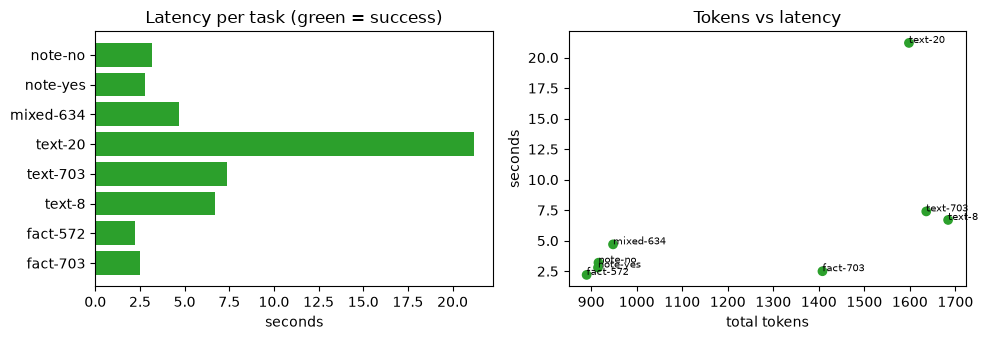

In [69]:
by_kind = assistant_eval.groupby("kind", sort=False).agg(tasks=("task", "count"), success=("success", "mean"),
                                                        model_calls=("model_calls", "mean"), tokens=("tokens", "mean"),
                                                        seconds=("seconds", "mean")).round(2)
print(by_kind.to_string(), "\n")

rate = assistant_eval.success.mean()
print(f"overall success: {assistant_eval.success.sum()}/{len(assistant_eval)} ({rate:.0%}) on this run")
print(f"mean per task: {assistant_eval.model_calls.mean():.1f} model calls, {assistant_eval.tool_calls.mean():.1f} tool calls, "
      f"{assistant_eval.tokens.mean():.0f} tokens, {assistant_eval.seconds.mean():.1f}s")
slowest = by_kind.seconds.idxmax()
print(f"slowest task kind: '{slowest}' ({by_kind.loc[slowest, 'seconds']:.1f}s mean) — "
      f"{by_kind.loc[slowest, 'model_calls']:.1f} model calls vs {assistant_eval.model_calls.mean():.1f} overall")
if assistant_eval.tokens.std() > 0 and assistant_eval.seconds.std() > 0:
    print(f"correlation of tokens with latency across tasks: r = {assistant_eval.tokens.corr(assistant_eval.seconds):.2f} (n={len(assistant_eval)})")
actions = assistant_eval[assistant_eval.kind == "action"]
print(f"approval gate: requested on {int((actions.approvals > 0).sum())}/{len(actions)} note tasks; "
      f"no approval requested on read-only tasks: {bool((assistant_eval[assistant_eval.kind != 'action'].approvals == 0).all())}")
failures = assistant_eval[~assistant_eval.success]
for _, row in failures.iterrows():
    print(f"❌ {row.task}: tools={row.tools or 'none'} error={row.error} answer={row.answer[:120]!r}")
if failures.empty:
    print("✅ every task succeeded on this run — with 8 tasks that is encouraging, not proof; add harder tasks next.")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
colors = ["tab:green" if s else "tab:red" for s in assistant_eval.success]
axes[0].barh(assistant_eval.task, assistant_eval.seconds, color=colors)
axes[0].set(xlabel="seconds", title="Latency per task (green = success)")
axes[1].scatter(assistant_eval.tokens, assistant_eval.seconds, c=colors)
for _, row in assistant_eval.iterrows():
    axes[1].annotate(row.task, (row.tokens, row.seconds), fontsize=7)
axes[1].set(xlabel="total tokens", ylabel="seconds", title="Tokens vs latency")
plt.tight_layout()
plt.show()

**Stretch goals**

1. Replace the hand-written agent loop with `create_agent(..., middleware=[HumanInTheLoopMiddleware(...)], checkpointer=...)` and compare success, steps, and tokens on the same task set.
2. Add the corrective-RAG graph from Section 16 as a **subgraph tool** and check whether the `search` tasks improve.
3. Grow the task set to 30+ tasks (include unanswerable questions and prompt-injection text inside a note request), and report success with a confidence interval.
4. Swap `SqliteSaver` for `PostgresSaver` and run the approval from a separate script to prove cross-process resume.

### 🗣️ How to talk about this in an interview
- "I built a LangGraph assistant with an agent node, a read-only tool node, and an approval node that interrupts **before** any side effect; state is checkpointed in SQLite, so a paused approval survives a process restart — I demonstrated that by rebuilding the graph on the same database."
- "Retrieval is a tool over a vector store of real PEPs, and factual lookups use a structured metadata tool, so the model never has to guess header facts."
- "I evaluated on a labeled task set with expected strings grounded in the documents, tracking success, model and tool calls, tokens, and latency per task type — the numbers above come from that run."
- "Safety is enforced in code, not the prompt: a hard cap on model calls, a recursion limit, an allow-list of tools, and mandatory approval for writes."
- "Next steps would be a larger task set with unanswerable and adversarial cases, tracing in production, and comparing against the prebuilt `create_agent` with HITL middleware."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is LCEL, and what does the Runnable interface buy you?**

<details><summary>Show answer</summary>

- **30-second answer:** LCEL is LangChain's `|` composition syntax. Every component (prompt, model, retriever, parser, function) implements the Runnable interface — `invoke`, `batch`, `stream` and async twins — so any composition automatically supports batching, streaming, async, retries/fallbacks, config, and callbacks/tracing.
- **Go deeper:** Functions are wrapped as `RunnableLambda`, dicts as `RunnableParallel`; `RunnablePassthrough.assign` adds keys. The overhead is a few hundred microseconds per call (measured in Section 1), negligible next to LLM latency. For control flow with loops and state, move to LangGraph.
- **❌ Common wrong answer:** "LCEL makes the LLM faster" or "LCEL is required to use LangChain models." It is just composition; you can call `llm.invoke` directly.

</details>

**Q2. Chain vs agent vs LangGraph graph — when do you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** A chain is a fixed sequence (predictable, cheap). An agent lets the model choose tools and when to stop (flexible, less predictable). A LangGraph graph is explicit control flow with state — you decide which parts are fixed and where the model decides, and you get checkpoints, interrupts, and streaming.
- **Go deeper:** Start with the simplest workflow that meets the need ("workflows before agents"). `create_agent` is itself a prebuilt LangGraph graph; drop to a custom `StateGraph` when you need custom routing, approvals, parallel steps, or subgraphs.
- **❌ Common wrong answer:** "Always use an agent because it's more powerful."

</details>

**Q3. Walk through tool calling end to end. Who executes the tool?**

<details><summary>Show answer</summary>

- **30-second answer:** The app sends messages plus JSON schemas of the tools. The model returns an assistant message with `tool_calls` (name, JSON arguments, id). **The application** validates and runs the function, appends a tool message with the result and the same id, and calls the model again until it answers in text.
- **Go deeper:** Schemas come from function signatures and docstrings (`@tool`), so argument descriptions are part of the prompt. Handle invalid args and errors as tool messages so the model can recover; cap iterations; require approval for side effects. Some models emit parallel tool calls; ours emitted them one at a time, so loops must handle both.
- **❌ Common wrong answer:** "The model runs the Python function itself."

</details>

**Q4. What is a checkpointer in LangGraph, and what does it enable?**

<details><summary>Show answer</summary>

- **30-second answer:** It saves the graph state after every super-step, keyed by `thread_id`. That enables conversation memory, resuming after failures, human-in-the-loop pauses, and time travel (inspect, replay, or fork earlier checkpoints).
- **Go deeper:** `InMemorySaver` for tests, `SqliteSaver` for single machines, `PostgresSaver` for production. Resume a failed run with `graph.invoke(None, config)`; completed steps don't re-run, so nodes should be idempotent. Checkpoints hold the full state — keep it small and don't store secrets in it.
- **❌ Common wrong answer:** "It's a cache of LLM responses."

</details>

**Q5. How does `interrupt()` work, and why must the code before it be idempotent?**

<details><summary>Show answer</summary>

- **30-second answer:** `interrupt(payload)` raises a special signal, the checkpointer saves state, and the caller gets the payload under `__interrupt__`. Resuming with `Command(resume=value)` **re-runs the node from the top**, and this time `interrupt()` returns `value`. Anything before the interrupt runs twice.
- **Go deeper:** Put side effects after the interrupt or in a separate node; with several interrupts in one node, they are matched by order, so keep that order stable. `HumanInTheLoopMiddleware` wraps the same mechanism for `create_agent` tools with approve/edit/reject/respond decisions.
- **❌ Common wrong answer:** "The graph resumes from the exact line where it paused, like a debugger."

</details>

**Q6. What are state reducers and when are they required?**

<details><summary>Show answer</summary>

- **30-second answer:** A reducer defines how an update combines with the current value of a key (e.g. `Annotated[list, operator.add]` appends). Without one, the last write wins — and two parallel nodes writing the same key in one step raise `InvalidUpdateError`.
- **Go deeper:** `add_messages` appends, replaces by message id, and deletes with `RemoveMessage`. `Overwrite(value)` bypasses a reducer once. Map-reduce with `Send` relies on a reducer to collect results. Reducers also apply to input you send to an existing thread.
- **❌ Common wrong answer:** "Reducers are only for message lists."

</details>

**Q7. How do you get reliable structured output from an LLM with LangChain?**

<details><summary>Show answer</summary>

- **30-second answer:** `llm.with_structured_output(PydanticModel)` with `method="json_schema"` (server-side constrained decoding) or `"function_calling"`; validate with Pydantic; use `include_raw=True` to log and retry parse failures; measure valid-schema rate and field accuracy on labeled data.
- **Go deeper:** `json_mode` only guarantees valid JSON — in Section 5 it produced 0% schema-valid output because the keys weren't in the prompt. Keep schemas small with clear field descriptions, and allow `null` for fields that may be absent.
- **❌ Common wrong answer:** "Just ask for JSON in the prompt and `json.loads` it."

</details>

### 💻 Coding

**Q8. Write a minimal tool-calling loop without an agent framework.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  messages = [HumanMessage(question)]
  for _ in range(MAX_STEPS):
      ai = llm.bind_tools(tools).invoke(messages); messages.append(ai)
      if not ai.tool_calls: return ai.content
      for call in ai.tool_calls:
          messages.append(tools_by_name[call["name"]].invoke(call))   # returns a ToolMessage with the call id
  raise RuntimeError("step limit reached")
  ```
- **Go deeper:** Validate the tool name against an allow-list, catch tool exceptions into error tool messages, log each step with tokens and latency, and gate side-effecting tools behind approval.
- **❌ Common wrong answer:** A `while True` loop with no step limit, or dropping the `tool_call_id` so the model can't match results to calls.

</details>

**Q9. Implement map-reduce summarization over N documents in LangGraph.**

<details><summary>Show answer</summary>

- **30-second answer:** State has `docs: list` and `summaries: Annotated[list, operator.add]`. A conditional edge from `START` returns `[Send("summarize", {"doc": d}) for d in state["docs"]]`; `summarize` returns `{"summaries": [summary]}`; an edge from `summarize` to `combine` produces the final summary once all branches finish.
- **Go deeper:** Limit concurrency with `max_concurrency` in the config, handle long inputs by collapsing summaries recursively when they exceed the context window, and add a retry policy on the map node.
- **❌ Common wrong answer:** A Python for-loop inside one node (no parallelism, no per-item retries or checkpoints).

</details>

### 🐛 Debugging Scenarios

**Q10. Your agent on a reasoning model sometimes returns an empty answer. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** `response_metadata["finish_reason"]`. If it is `"length"`, the hidden reasoning consumed `max_tokens` before the visible answer started (Pitfall 2). Raise the budget, lower the reasoning effort, or shorten the prompt.
- **Go deeper:** Also check that the model didn't end on a tool call you never executed, that the context window (8K per slot on our server) wasn't exceeded by retrieved text, and log `usage_metadata` to see reasoning-heavy calls.
- **❌ Common wrong answer:** "The model is broken — switch providers."

</details>

**Q11. After upgrading, `from langchain.chains import RetrievalQA` fails. How do you fix the app?**

<details><summary>Show answer</summary>

- **30-second answer:** LangChain 1.x removed legacy chains and agents from the main package. Short term, the `langchain-classic` package restores them; the real fix is to rewrite the chain as LCEL (retriever → prompt → model → parser) or a LangGraph graph, and `AgentExecutor` as `create_agent`.
- **Go deeper:** Pin versions, read the v1 migration guide, and add a smoke test that imports and runs the chain in CI so upgrades fail loudly. Avoid `langchain-community` for new code; use the standalone integration packages.
- **❌ Common wrong answer:** "Downgrade to 0.0.x forever."

</details>

**Q12. A resumed LangGraph run sent the same notification email twice. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The email was sent in a node before `interrupt()` (or in a node that crashed after sending). On resume the node re-runs from the top, so the side effect repeated (Pitfall 5).
- **Go deeper:** Move side effects after the interrupt or into their own node, and make them idempotent with an idempotency key (e.g. `thread_id + step`) that the email service checks.
- **❌ Common wrong answer:** "The checkpointer is corrupted."

</details>

### 🏗️ Design

**Q13. Design a customer-support agent that answers from company docs, looks up orders, and can issue refunds.**

<details><summary>Show answer</summary>

- **30-second answer:** A LangGraph graph: an agent node with tools (`search_docs` RAG tool, `get_order` read-only API, `issue_refund` write tool), a tool node, and an approval node that interrupts before refunds above a threshold. Durable Postgres checkpointer keyed by ticket id; streaming to the UI; tracing on every step.
- **Go deeper:** Guardrails in code (refund limits, allow-listed tools, authentication passed in runtime context, not in the prompt), prompt-injection defences for retrieved text, corrective retrieval with abstention, step and cost limits, and an offline task set (success, steps, tokens, latency) plus online feedback. Roll out with shadow mode and human review.
- **❌ Common wrong answer:** "Give the LLM the refund API and tell it in the system prompt to be careful."

</details>

**Q14. When would you *not* use LangChain or LangGraph?**

<details><summary>Show answer</summary>

- **30-second answer:** For a single model call or a short fixed pipeline, a provider SDK plus a few functions is simpler, easier to debug, and has fewer dependencies. Also when you need a brand-new provider feature before the integration supports it, or when the team can't own the abstraction.
- **Go deeper:** The measured framework overhead is tiny, so the decision is about complexity and churn. LangGraph earns its place when you need durable state, interrupts, retries, and streaming across many steps; LlamaIndex is a strong alternative for document-heavy retrieval (next notebook).
- **❌ Common wrong answer:** "Frameworks are always slower" (not measurably) or "you always need a framework for RAG" (you built RAG from scratch in the previous notebook).

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `(RunnableLambda(lambda x: x + 1) | (lambda x: x * 2)).invoke(3)`
<details><summary>Answer</summary>

`8` — the function on the right is wrapped in a `RunnableLambda`; `(3 + 1) * 2`.
</details>

**2.** `RunnableParallel(a=lambda x: x, b=lambda x: x * 2).invoke(5)`
<details><summary>Answer</summary>

`{'a': 5, 'b': 10}` — both branches get the same input.
</details>

**3.** Two nodes start from `START` in parallel and both return `{"items": [...]}`, where `items: list` has **no** reducer. What happens?
<details><summary>Answer</summary>

`InvalidUpdateError` — "Can receive only one value per step". Add `Annotated[list, operator.add]`.
</details>

**4.** `len(add_messages([HumanMessage("hi", id="1"), AIMessage("hello", id="2")], [AIMessage("hey", id="2")]))`
<details><summary>Answer</summary>

`2` — a message with an existing id **replaces** it instead of being appended.
</details>

**5.** A checkpointed graph failed in its third node. What does `graph.invoke(None, config)` with the same `thread_id` do?
<details><summary>Answer</summary>

It resumes from the last saved checkpoint: only the failed node (and what follows) runs; the first two nodes are not executed again.
</details>

## 📚 Resources

### 📖 Official Docs
- [LangChain overview (Python)](https://docs.langchain.com/oss/python/langchain/overview) — models, messages, tools, agents in LangChain 1.x
- [LangChain agents](https://docs.langchain.com/oss/python/langchain/agents) — `create_agent` and middleware
- [Structured output](https://docs.langchain.com/oss/python/langchain/structured-output) — schemas, strategies, and validation
- [LangGraph overview](https://docs.langchain.com/oss/python/langgraph/overview) — the graph runtime and when to use it
- [LangGraph persistence](https://docs.langchain.com/oss/python/langgraph/persistence) — checkpointers, threads, time travel
- [LangGraph interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts) — human-in-the-loop patterns and rules
- [LangGraph streaming](https://docs.langchain.com/oss/python/langgraph/streaming) — every stream mode
- [LangChain v1 migration guide](https://docs.langchain.com/oss/python/migrate/langchain-v1) — what moved and what was removed

### 🎥 Videos
- [freeCodeCamp.org (Vaibhav Mehra) — LangGraph Complete Course for Beginners – Complex AI Agents with Python](https://www.youtube.com/watch?v=jGg_1h0qzaM) (~3 h) — builds graphs, agents, and RAG step by step; good for hands-on repetition of Sections 10–16
- [James Briggs — LangChain Expression Language (LCEL) Explained!](https://www.youtube.com/watch?v=O0dUOtOIrfs) (~27 min) — clear walkthrough of pipes, `RunnableParallel`, and `RunnablePassthrough` (an older LangChain version, but the LCEL ideas are unchanged)
- [LangChain — LangChain Academy New Course: LangGraph Essentials](https://www.youtube.com/watch?v=B_BCeWhyD5Q) (short) — the official introduction to the current LangGraph course

### 📄 Papers & Articles
- [Yao et al. (2022) — ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629) — the reason-act-observe loop behind tool-using agents
- [Yan et al. (2024) — Corrective Retrieval Augmented Generation](https://arxiv.org/abs/2401.15884) — the CRAG idea from Section 16
- [Asai et al. (2023) — Self-RAG](https://arxiv.org/abs/2310.11511) — a model that decides when to retrieve and critiques its own output
- [Anthropic — Building effective agents](https://www.anthropic.com/engineering/building-effective-agents) — workflows vs agents, and why simple patterns usually win

### 📘 Books & Courses
- [LangChain Academy — Introduction to LangGraph](https://academy.langchain.com/courses/intro-to-langgraph) — free official course with notebooks

### 🏋️ Practice
- [LangGraph on GitHub](https://github.com/langchain-ai/langgraph) — examples and source; reading `StateGraph` and the Pregel loop is great interview prep
- [The PEP repository](https://github.com/python/peps) — the real documents used here; add more PEPs and grow the evaluation sets

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Framework choice | adopt for features, not "chains" | raw SDK for simple calls; LangGraph for stateful multi-step apps |
| Chat model | messages in, `AIMessage` out | `ChatOpenAI(base_url=…)`, `.usage_metadata`, `finish_reason` |
| Prompt template | reusable prompts with blanks | `ChatPromptTemplate.from_messages`, `MessagesPlaceholder`, `.partial` |
| LCEL | compose Runnables | `a \| b`, `RunnableParallel`, `RunnablePassthrough.assign`, `.with_retry`, `.with_fallbacks` |
| Concurrency | faster I/O-bound calls | `batch(max_concurrency=k)`, `ainvoke` + semaphore, `stream`, `astream_events` |
| Structured output | validated objects | `with_structured_output(Model, method="json_schema", include_raw=True)` |
| Tools | model requests, app executes | `@tool(parse_docstring=True)`, `bind_tools`, `ToolMessage`, `ToolException` |
| Agent | model-driven tool loop | `create_agent(model, tools, middleware=[…], response_format=…)` |
| Retrieval | find relevant chunks | `BaseLoader`, `RecursiveCharacterTextSplitter`, `InMemoryVectorStore`, `as_retriever(k)` |
| RAG with citations | grounded answers | numbered sources + structured `citations`, verified in code |
| StateGraph | explicit control flow | `add_node`, `add_edge`, `add_conditional_edges`, `START`/`END`, `compile()` |
| Reducers | combine updates | `Annotated[list, operator.add]`, `add_messages`, `Overwrite`, `Send` |
| Checkpointer | memory, resume, time travel | `InMemorySaver`/`SqliteSaver`, `thread_id`, `invoke(None, cfg)`, `get_state_history` |
| Interrupts | human approval | `interrupt(payload)`, `Command(resume=…)`, side effects after the interrupt |
| Streaming | progress for UIs | `stream_mode=["updates","messages","custom"]`, `version="v2"`, `get_stream_writer` |
| Robustness | survive failures | `RetryPolicy`, `error_handler` + `NodeError`, `recursion_limit`, subgraphs |
| Corrective RAG | grade → rewrite → abstain | measure accuracy, abstention, and extra LLM calls |
| Tracing | see every step | LangSmith (key), `BaseCallbackHandler`, `get_usage_metadata_callback` |

## ➡️ What's Next

**[04 · LlamaIndex](04_LlamaIndex.ipynb)** — the other major framework, built around documents and indexes: ingestion pipelines, hybrid retrieval with fusion and reranking, response synthesizers, workflows and agents — using the same PEP collection, so you can compare the two frameworks directly.